# Ball Mapper construction and analysis

## Purpose
Construct the Ball Mapper representation of TTWA creative-industry
specialisation and use it to explore how specialisation patterns relate
to local socio-economic and urban-rural context. Produces the figures and
ball-level tables used in Section 4 of the report.

## Input
- `data/processed/nesta_ball.csv` (sector LQs)
- `data/processed/census_filtered.csv` (contextual variables, matched by TTWA name)

## Main parameters
- Seven creative-industry sector LQs
- RobustScaler
- Epsilon = 3.0
- Fixed layout seed (42) for visualisation
- Colour scales clipped to the 5th–95th percentiles of principal-component balls;
  sector LQ plots centred on LQ = 1

## Main steps
- Build the Ball Mapper graph for 173 England & Wales TTWAs
  (30 balls: a principal component of 16 balls, plus 14 disconnected single balls)
- Plot the baseline graph, with disconnected balls shown in a separate strip
- Colour the graph by mean ball value for each of the seven sector LQs
- Colour the graph by each of the 13 census contextual variables
- Build a ball profile table: size, component status, member TTWAs,
  mean sector LQs, and dominant and second sector
- Identify the dominant sector for each TTWA in the disconnected balls
- Count TTWAs with no sub-sector LQ above 1 (65 of 173)
- Summarise census variables by ball (mean, SD, min, median, max) and add
  ball-level means to the profile table

## Output
- Baseline and coloured Ball Mapper figures (7 sector, 13 census)
- `ball_profiles_census.csv`: ball-level sector profiles
- In-notebook tables: disconnected-ball TTWAs, ball-level census summaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.preprocessing import RobustScaler
from pyballmapper import BallMapper
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.cm import ScalarMappable

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
nesta = pd.read_csv(
    "/Users/scandimimi/Documents/Manchester/ERP/nesta_ball.csv"
).reset_index(drop=True)

lq_cols = [
    "Advertising and marketing: Employment 2011-2014_LQ",
    "Architecture: Employment 2011-2014_LQ",
    "Design: product, graphic and fashion design: Employment 2011-2014_LQ",
    "Film, TV, video, radio and photography: Employment 2011-2014_LQ",
    "IT, software and computer services: Employment 2011-2014_LQ",
    "Music, performing and visual arts: Employment 2011-2014_LQ",
    "Publishing: Employment 2011-2014_LQ",
]

assert len(nesta) == 173
assert nesta["ttwa"].nunique() == 173
assert nesta[lq_cols].notna().all().all()

X = nesta[lq_cols].copy()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

assert X_scaled.shape == (173, 7)

In [3]:
EPSILON = 3.0

bm = BallMapper(X_scaled, eps=EPSILON)
G_full = bm.Graph.copy()

ball_members = {
    ball: list(bm.points_covered_by_landmarks[ball])
    for ball in G_full.nodes
}

covered_indices = set().union(
    *(set(indices) for indices in ball_members.values())
)

assert len(nesta) == 173
assert covered_indices == set(range(len(nesta)))
assert G_full.number_of_nodes() == 30

components = sorted(
    nx.connected_components(G_full),
    key=len,
    reverse=True
)

main_nodes = set(components[0])
disconnected_nodes = sorted(
    node for node in G_full.nodes
    if node not in main_nodes
)

print("TTWAs covered:", len(covered_indices))
print("Total balls:", G_full.number_of_nodes())
print("Components:", len(components))
print("Component sizes:", [len(c) for c in components])
print("Disconnected balls:", disconnected_nodes)

TTWAs covered: 173
Total balls: 30
Components: 15
Component sizes: [16, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Disconnected balls: [5, 9, 10, 15, 16, 20, 21, 22, 23, 24, 25, 26, 27, 29]


Asserting that all balls will be visible

In [4]:
node_size_dict = {
    ball: max(len(ball_members[ball]) * 25, 600)
    for ball in G_full.nodes
}

assert set(node_size_dict) == set(G_full.nodes)

Producing one shared full-graph layout

In [5]:
def make_full_ballmapper_layout(
    G,
    seed=42,
    k=1.5,
    iterations=1000
):
    components = sorted(
        nx.connected_components(G),
        key=len,
        reverse=True
    )

    main_nodes = set(components[0])
    other_nodes = sorted(
        node for node in G.nodes
        if node not in main_nodes
    )

    # Spring layout only for the principal component
    pos = nx.spring_layout(
        G.subgraph(main_nodes),
        seed=seed,
        k=k,
        iterations=iterations
    )

    # Put disconnected balls in a clearly separated strip
    if other_nodes:
        main_x = [coordinates[0] for coordinates in pos.values()]
        main_y = [coordinates[1] for coordinates in pos.values()]

        strip_x = max(main_x) + 1.0
        strip_y = np.linspace(
            max(main_y),
            min(main_y),
            len(other_nodes)
        )

        for ball, y_position in zip(other_nodes, strip_y):
            pos[ball] = (strip_x, y_position)

        layout_information = {
            "strip_x": strip_x,
            "divider_x": strip_x - 0.5,
            "main_heading_x": np.mean(main_x),
            "heading_y": max(main_y) + 0.18
        }

    else:
        layout_information = None

    assert set(pos) == set(G.nodes)

    return pos, main_nodes, other_nodes, layout_information


(
    pos_full,
    main_nodes,
    disconnected_nodes,
    layout_information
) = make_full_ballmapper_layout(G_full)

Shared annotations for the isolate strip:

In [6]:
def add_topology_annotations(
    ax,
    G,
    disconnected_nodes,
    layout_information
):
    if disconnected_nodes and layout_information is not None:

        ax.axvline(
            layout_information["divider_x"],
            color="#777777",
            linewidth=0.9,
            linestyle="--",
            alpha=0.7
        )

        ax.text(
            layout_information["main_heading_x"],
            layout_information["heading_y"],
            "Principal connected component",
            fontsize=10,
            fontweight="bold",
            ha="center"
        )

        ax.text(
            layout_information["strip_x"],
            layout_information["heading_y"],
            "Disconnected balls",
            fontsize=10,
            fontweight="bold",
            ha="center"
        )

    ax.text(
        0.015,
        0.015,
        (
            f"n = {len(nesta)} TTWAs | ε = {EPSILON}\n"
            f"{G.number_of_nodes()} balls | "
            f"{nx.number_connected_components(G)} components | "
            f"{len(disconnected_nodes)} disconnected balls\n"
            "Disconnected-ball ordering has no spatial interpretation"
        ),
        transform=ax.transAxes,
        fontsize=8.5,
        verticalalignment="bottom"
    )

In [7]:
def plot_ballmapper_baseline(
    G,
    pos,
    size_dict,
    disconnected_nodes,
    layout_information,
    title=(
        "Ball Mapper creative topology of "
        "English and Welsh TTWAs"
    )
):
    nodelist = list(G.nodes)
    node_sizes = [size_dict[ball] for ball in nodelist]

    fig, ax = plt.subplots(
        figsize=(15, 10),
        facecolor="white"
    )

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edge_color="#030304",
        width=0.8,
        alpha=0.5
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        nodelist=nodelist,
        node_size=node_sizes,
        node_color="#283e48",
        edgecolors="white",
        linewidths=0.8
    )

    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
        labels={ball: str(ball) for ball in nodelist},
        font_size=7,
        font_weight="bold",
        font_color="white"
    )

    add_topology_annotations(
        ax,
        G,
        disconnected_nodes,
        layout_information
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=24
    )

    ax.axis("off")
    ax.margins(x=0.08, y=0.12)
    fig.tight_layout()
    plt.show()

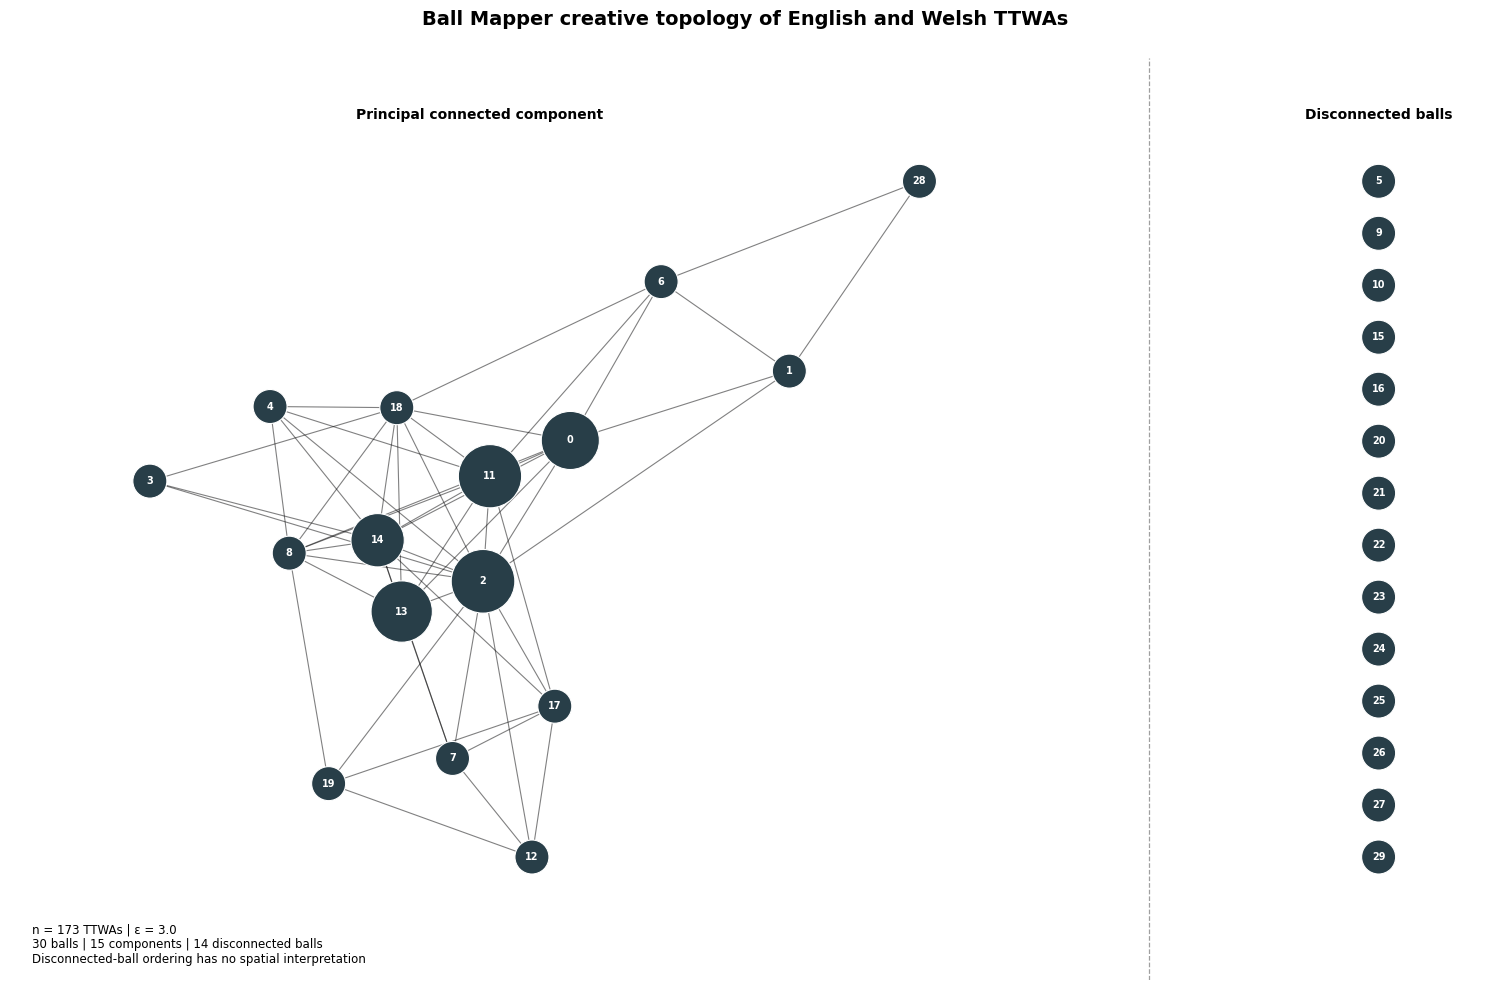

In [8]:
plot_ballmapper_baseline(
    G=G_full,
    pos=pos_full,
    size_dict=node_size_dict,
    disconnected_nodes=disconnected_nodes,
    layout_information=layout_information
)

Making the colouration plots by Nesta creative sub-sector

In [9]:
def plot_full_ballmapper_values(
    values_by_ball,
    title,
    cbar_label,
    G,
    pos,
    size_dict,
    disconnected_nodes,
    layout_information,
    centre=None,
    cmap_name="RdYlBu_r"
):
    nodelist = list(G.nodes)

    values = np.array(
        [values_by_ball[ball] for ball in nodelist],
        dtype=float
    )

    if np.isnan(values).all():
        raise ValueError(
            f"All calculated values are missing for: {cbar_label}"
        )

   
    main_component_values = np.array(
    [
        values_by_ball[ball]
        for ball in nodelist
        if ball not in disconnected_nodes
        and not np.isnan(values_by_ball[ball])
    ],
    dtype=float
    )

    if len(main_component_values) == 0:
        raise ValueError(
     "No valid principal-component values are available."
    )

    vmin, vmax = np.nanpercentile(
    main_component_values,
    [5, 95]
    )

    # Fallback if the percentile limits are identical
    if np.isclose(vmin, vmax):
        vmin = np.nanmin(main_component_values)
        vmax = np.nanmax(main_component_values)

    # Final fallback if all valid values are identical
    if np.isclose(vmin, vmax):
        vmin -= 0.001
        vmax += 0.001

    if centre is not None:

        # Ensure the reference value lies inside the scale
        vmin = min(vmin, centre - 0.001)
        vmax = max(vmax, centre + 0.001)

        norm = TwoSlopeNorm(
            vmin=vmin,
            vcenter=centre,
            vmax=vmax
        )

    else:
        norm = Normalize(
            vmin=vmin,
            vmax=vmax
        )

    cmap = plt.get_cmap(cmap_name)

    node_colours = [
        (
            cmap(norm(value))
            if not np.isnan(value)
            else (0.75, 0.75, 0.75, 1.0)
        )
        for value in values
    ]

    node_sizes = [
        size_dict[ball]
        for ball in nodelist
    ]

    fig, ax = plt.subplots(
        figsize=(15, 10),
        facecolor="white"
    )

    
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edge_color="#6f8792",
        width=0.8,
        alpha=0.5
    )

    
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        nodelist=nodelist,
        node_size=node_sizes,
        node_color=node_colours,
        edgecolors="white",
        linewidths=0.8
    )

    # Labels with automatic contrast
    for ball, colour in zip(
        nodelist,
        node_colours
    ):
        red, green, blue, _ = colour

        brightness = (
            0.299 * red +
            0.587 * green +
            0.114 * blue
        )

        label_colour = (
            "black"
            if brightness > 0.6
            else "white"
        )

        ax.text(
            pos[ball][0],
            pos[ball][1],
            str(ball),
            fontsize=7,
            fontweight="bold",
            ha="center",
            va="center",
            color=label_colour
        )

    
    colourbar_mapper = ScalarMappable(
        norm=norm,
        cmap=cmap
    )
    colourbar_mapper.set_array([])

    colourbar = fig.colorbar(
        colourbar_mapper,
        ax=ax,
        shrink=0.78,
        pad=0.03,
        extend="both"
    )

    colourbar.set_label(
        cbar_label,
        fontsize=10
    )

    # Topology and parameter annotations
    add_topology_annotations(
        ax,
        G,
        disconnected_nodes,
        layout_information
    )

    # Explain the robust colour limits
    ax.text(
        0.985,
        0.015,
        "Colour scale: 5th–95th percentiles of principal-component balls",
        transform=ax.transAxes,
        fontsize=8,
        ha="right",
        va="bottom",
        color="#555555"
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=24
    )

    ax.axis("off")
    ax.margins(x=0.08, y=0.12)

    fig.tight_layout()
    plt.show()

In [10]:
nesta_plots = {
    "Advertising and marketing: Employment 2011-2014_LQ": {
        "title": "Creative economy topology: advertising specialisation",
        "label": "Mean advertising and marketing LQ"
    },

    "Architecture: Employment 2011-2014_LQ": {
        "title": "Creative economy topology: architecture specialisation",
        "label": "Mean architecture LQ"
    },

    "Design: product, graphic and fashion design: Employment 2011-2014_LQ": {
        "title": "Creative economy topology: design specialisation",
        "label": "Mean design LQ"
    },

    "Film, TV, video, radio and photography: Employment 2011-2014_LQ": {
        "title": "Creative economy topology: film and television specialisation",
        "label": "Mean film, TV, video, radio and photography LQ"
    },

    "IT, software and computer services: Employment 2011-2014_LQ": {
        "title": "Creative economy topology: IT/software specialisation",
        "label": "Mean IT, software and computer services LQ"
    },

    "Music, performing and visual arts: Employment 2011-2014_LQ": {
        "title": "Creative economy topology: music and arts specialisation",
        "label": "Mean music, performing and visual arts LQ"
    },

    "Publishing: Employment 2011-2014_LQ": {
        "title": "Creative economy topology: publishing specialisation",
        "label": "Mean publishing LQ"
    }
}

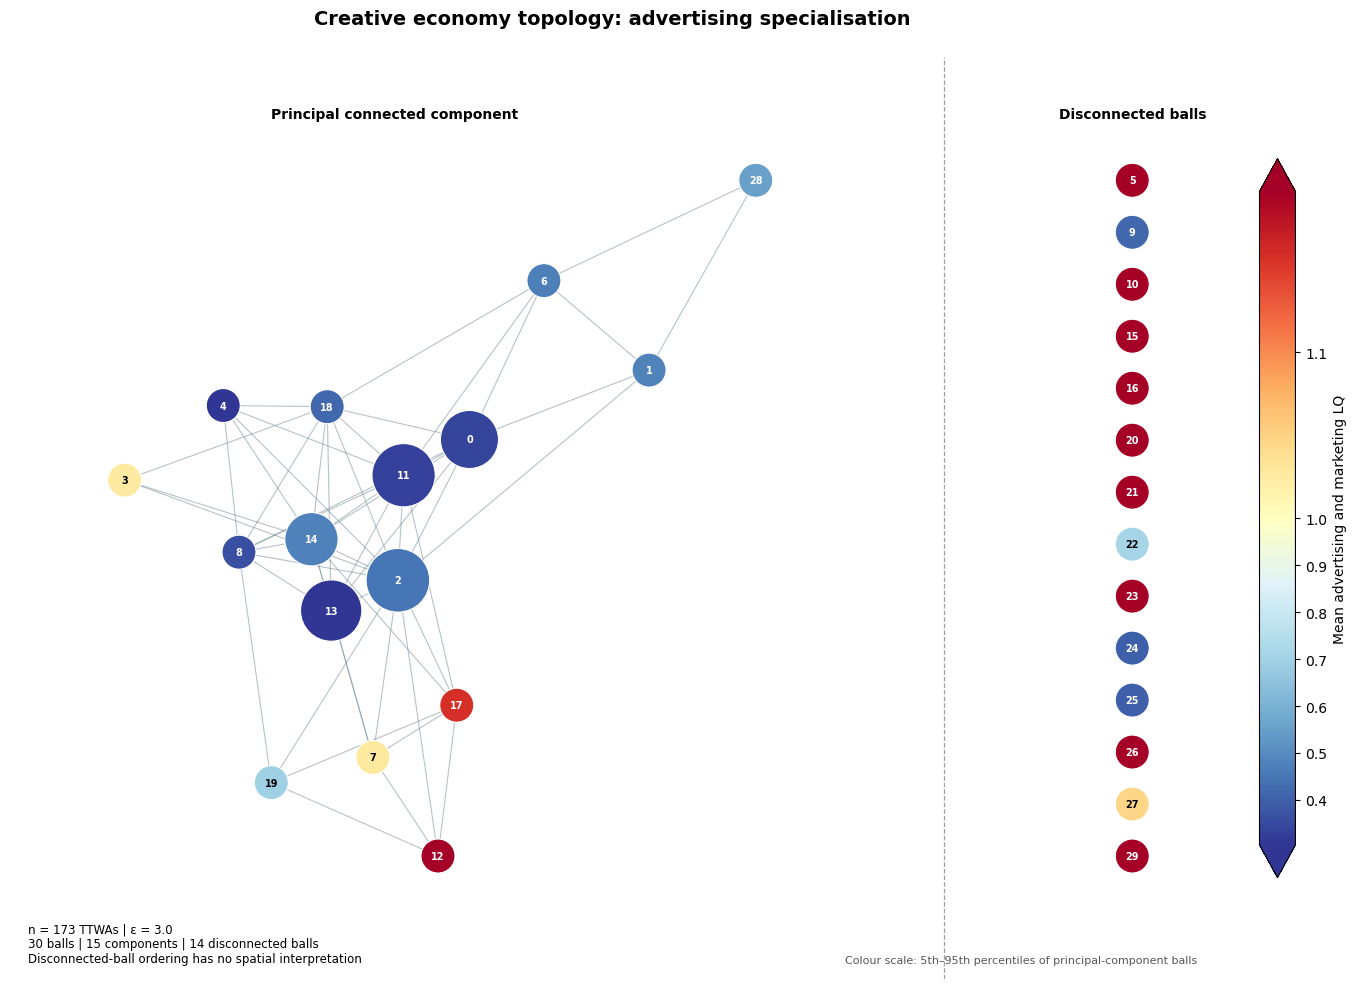

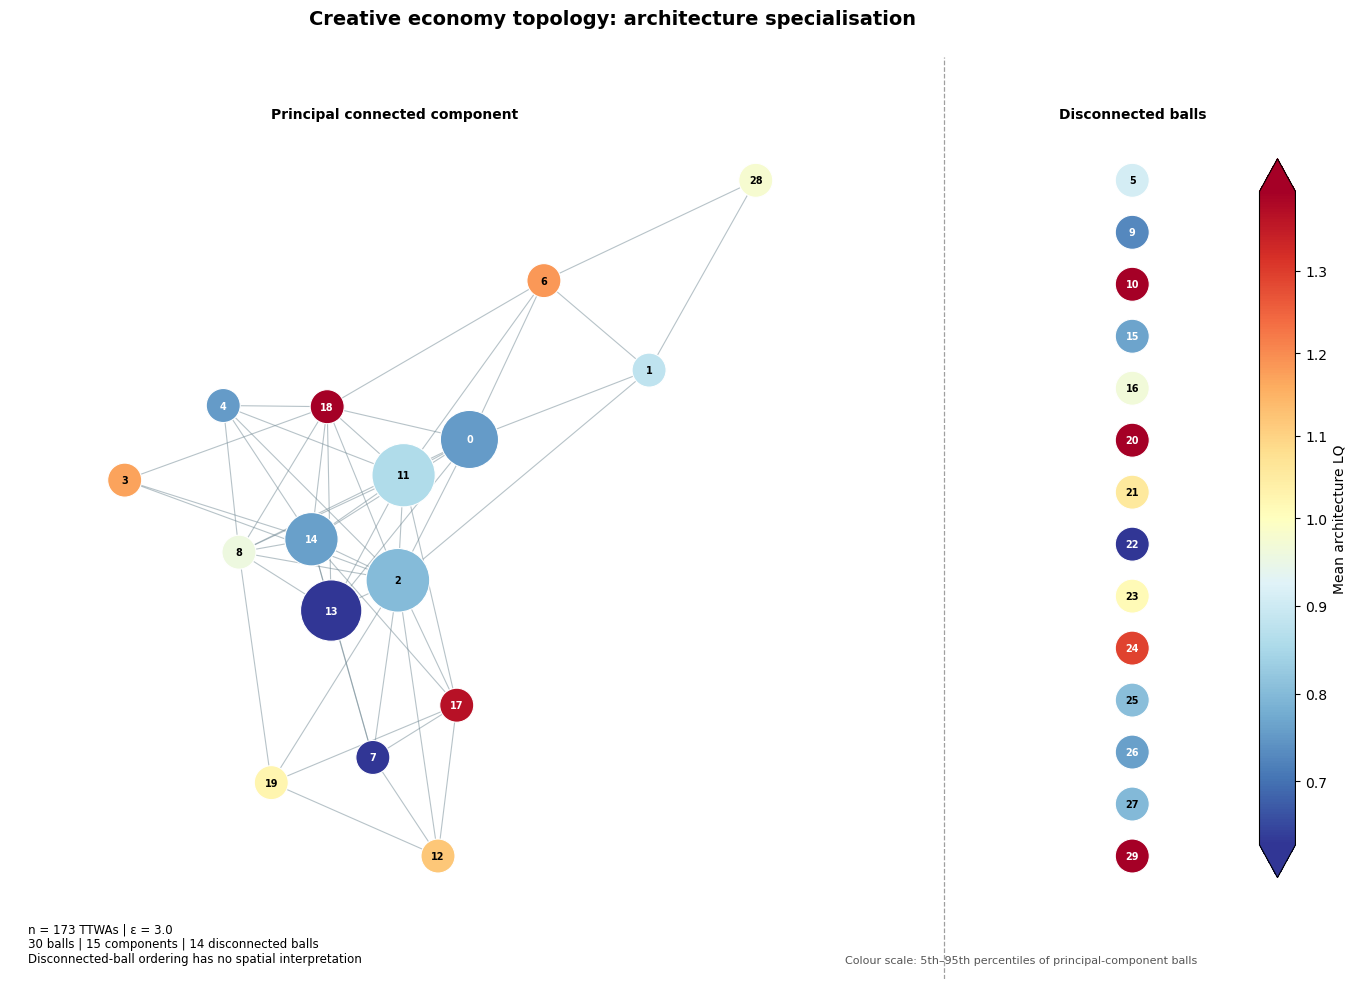

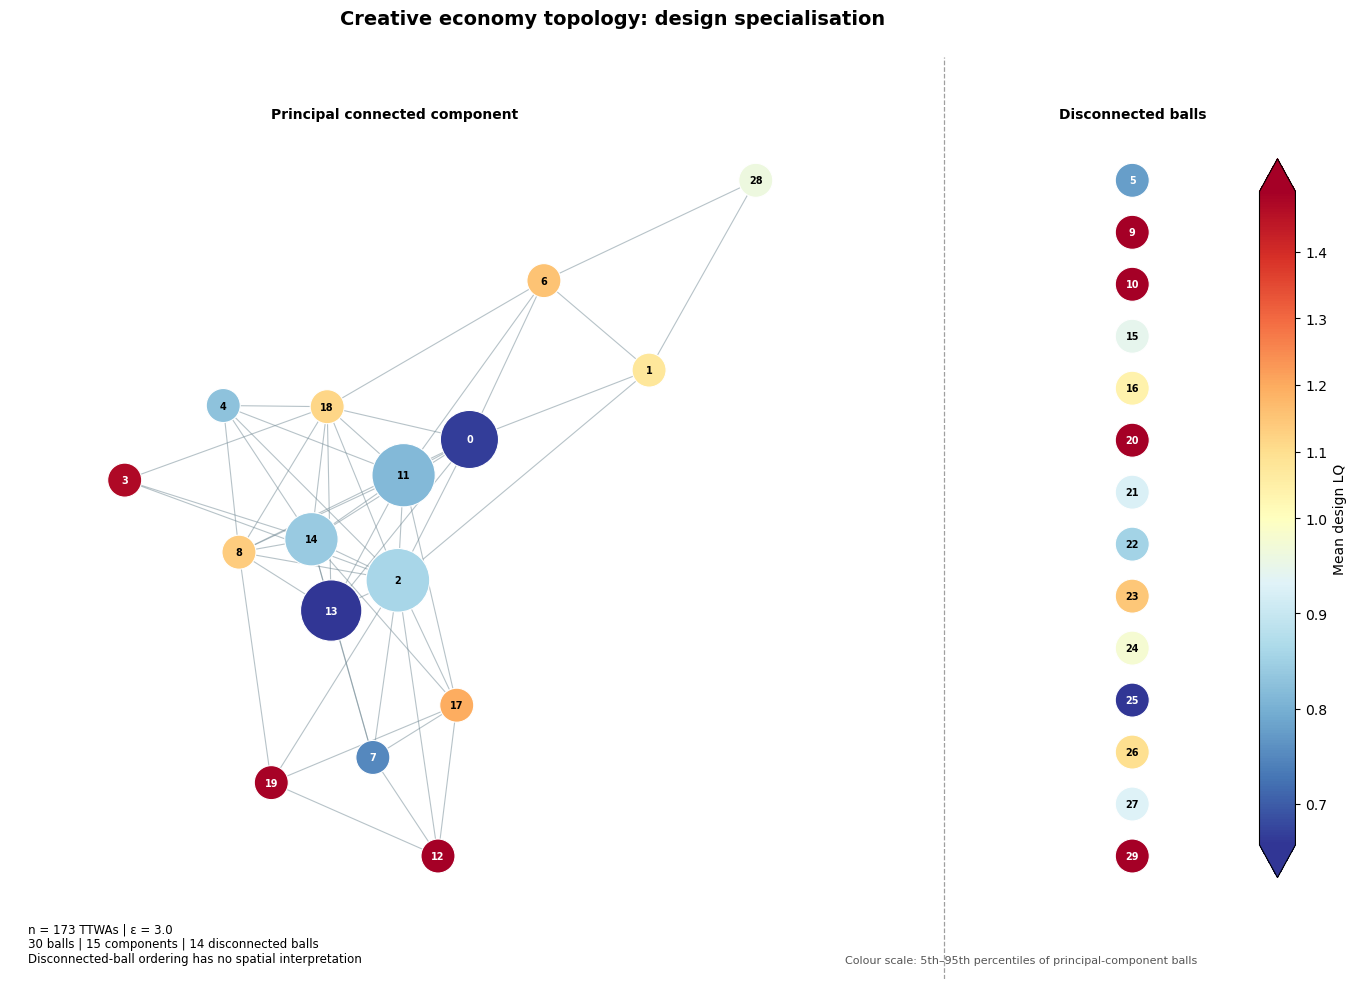

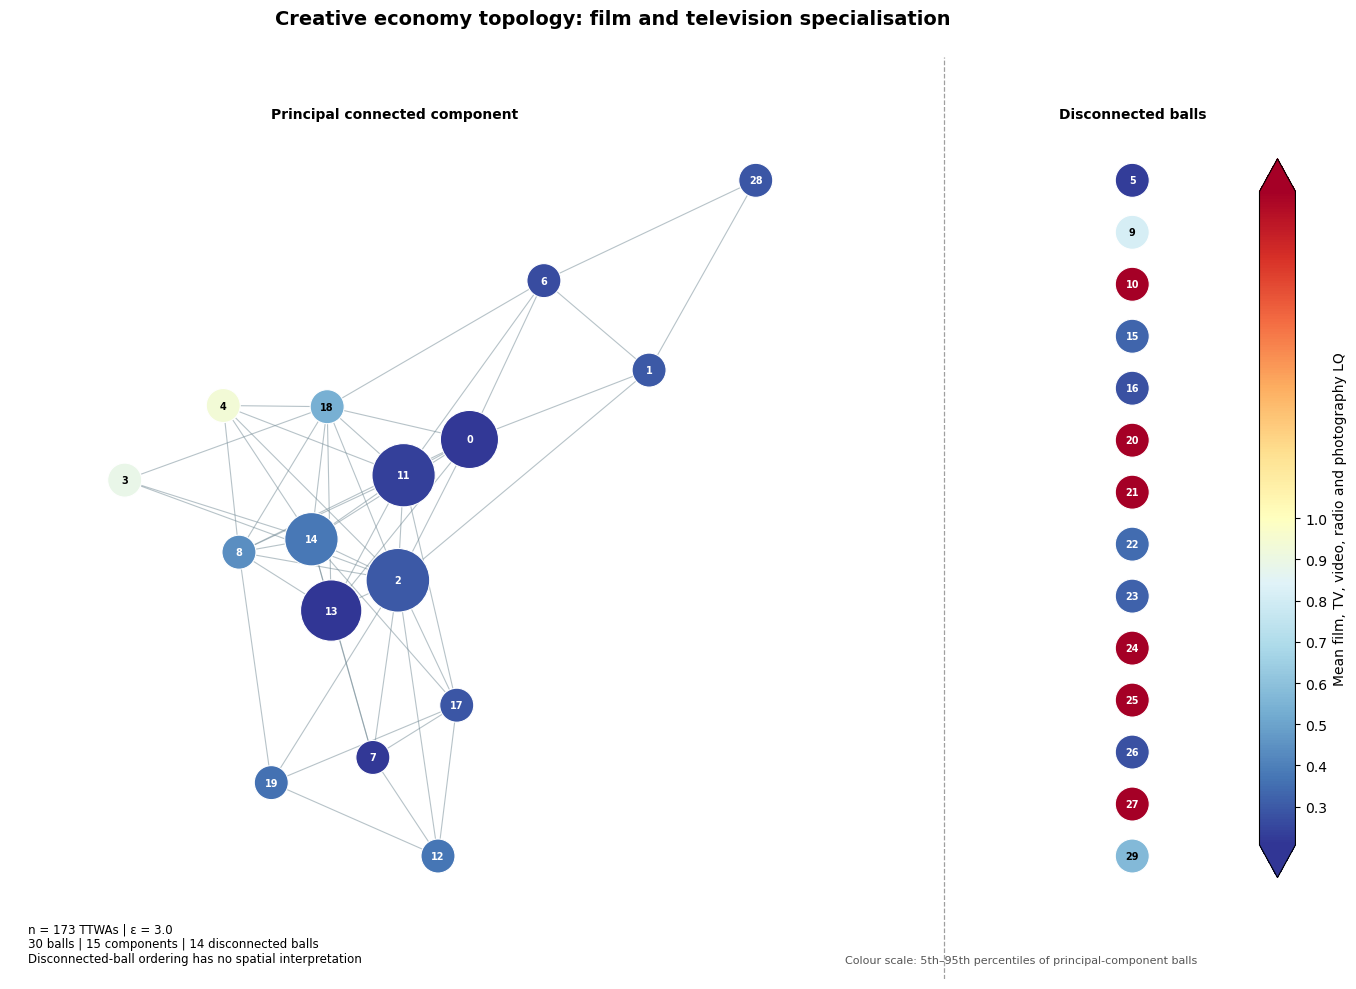

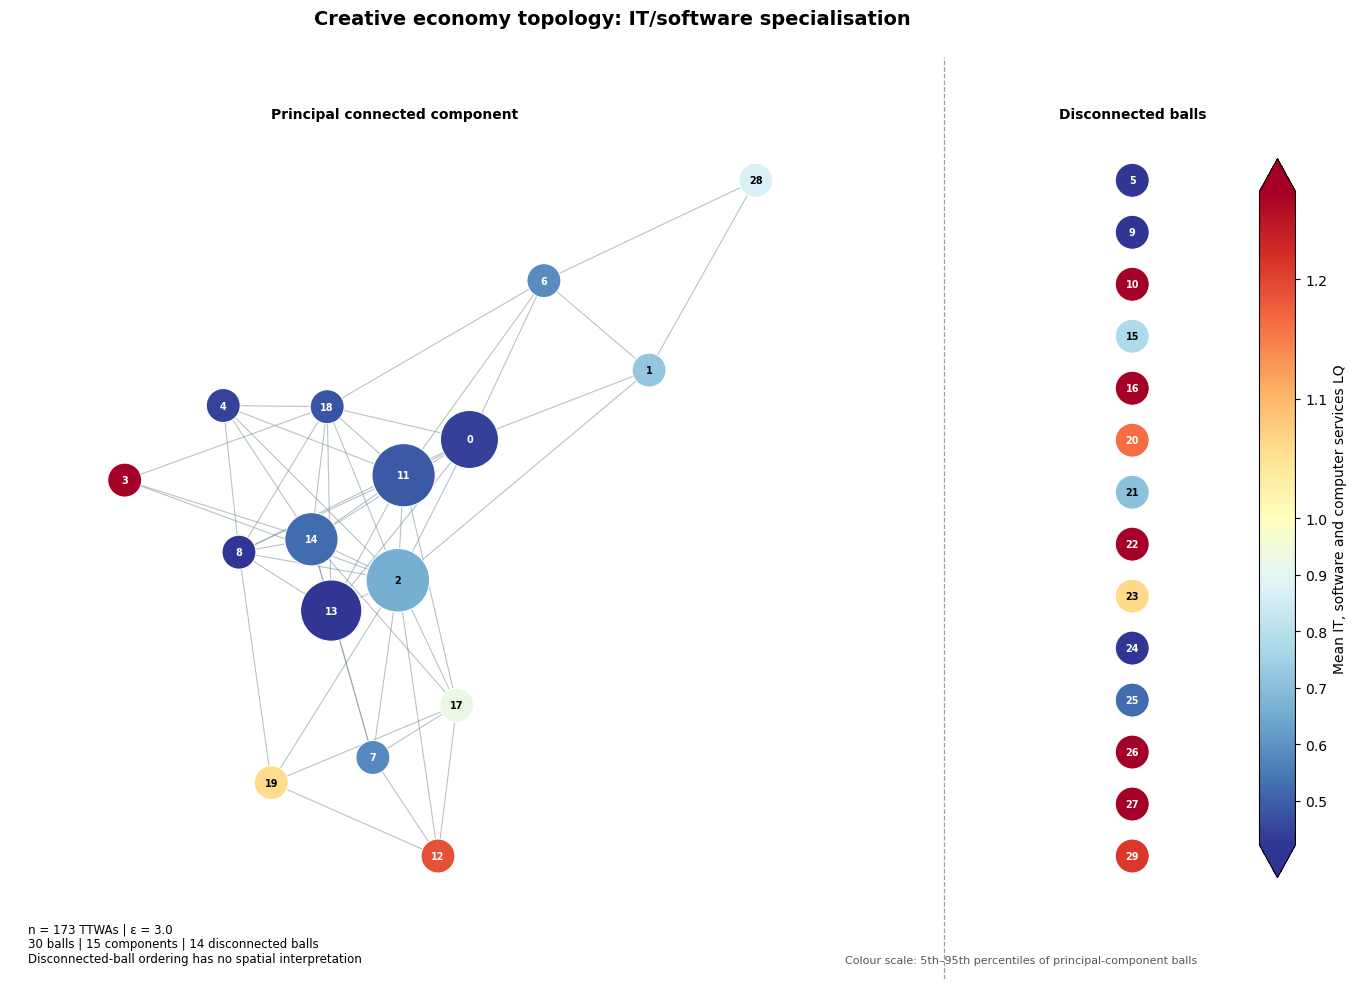

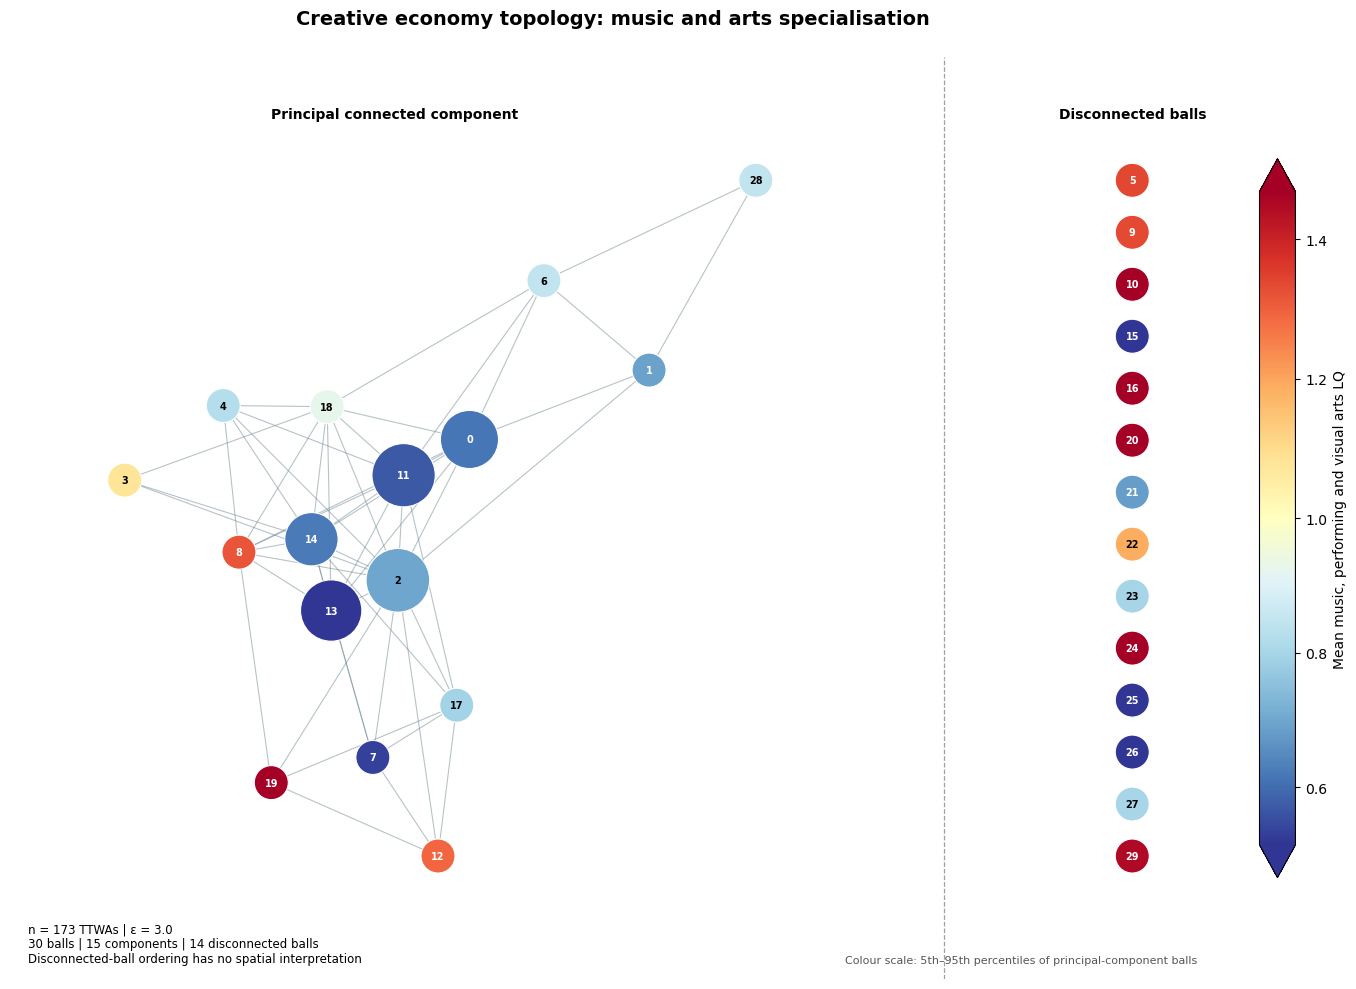

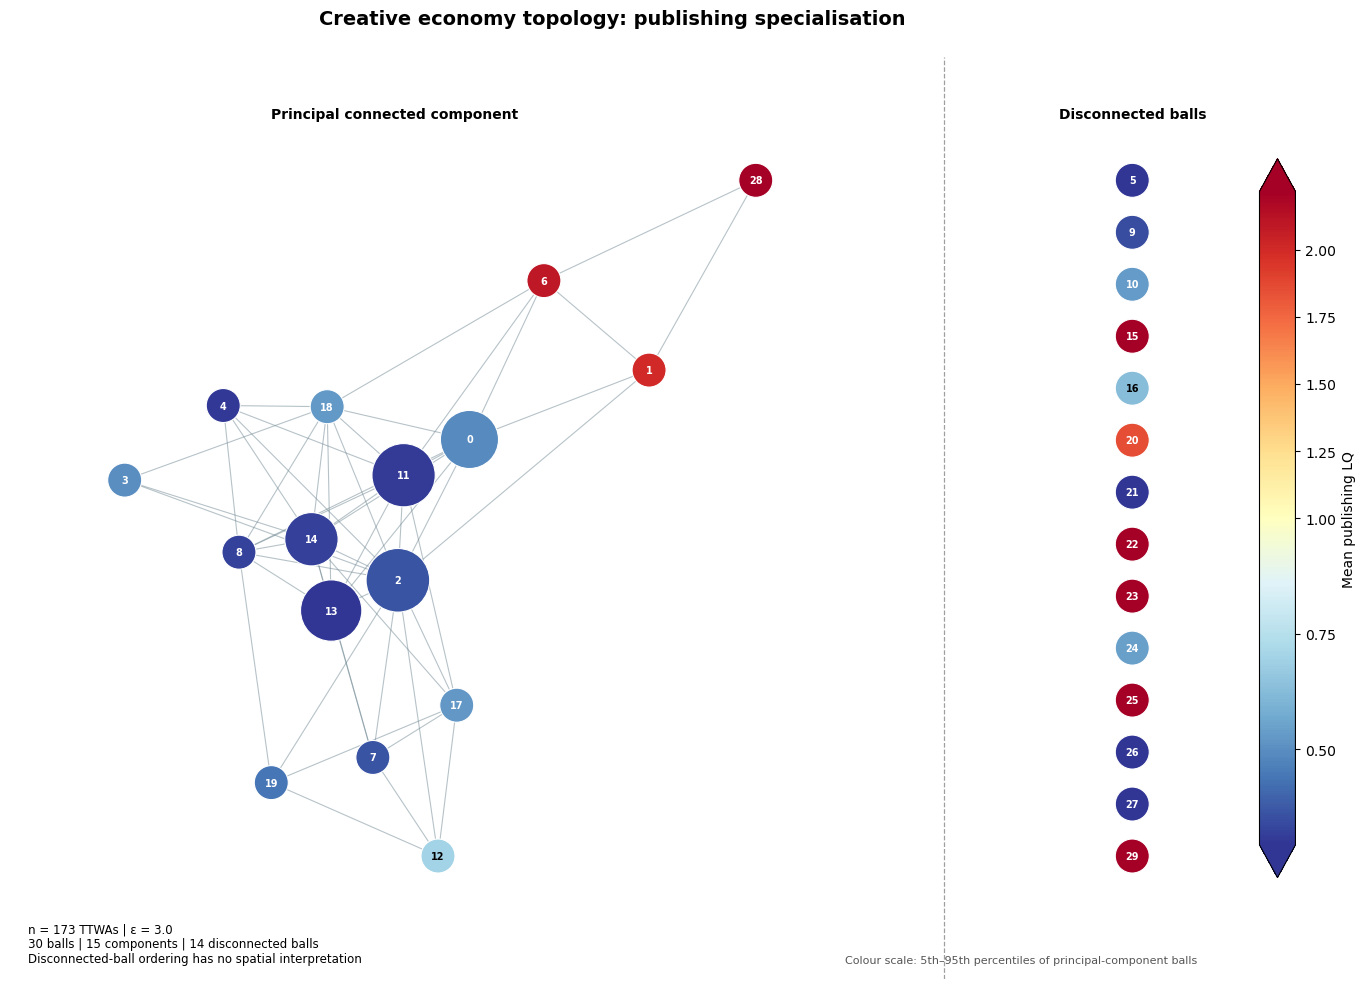

In [11]:
for sector_col, information in nesta_plots.items():

    values_by_ball = {
        ball: nesta.iloc[
            ball_members[ball]
        ][sector_col].mean()
        for ball in G_full.nodes
    }

    plot_full_ballmapper_values(
        values_by_ball=values_by_ball,
        title=information["title"],
        cbar_label=information["label"],
        G=G_full,
        pos=pos_full,
        size_dict=node_size_dict,
        disconnected_nodes=disconnected_nodes,
        layout_information=layout_information,
        centre=1.0,
        cmap_name="RdYlBu_r"
    )

Importing census data for ball mapper colouration:

In [12]:
census = pd.read_csv(
    "/Users/scandimimi/Documents/Manchester/ERP/census_filtered.csv"
)

missing_ttwas = (
    set(nesta["ttwa"]) -
    set(census["TTWA11NM"])
)

assert not missing_ttwas, (
    f"Missing census matches: {sorted(missing_ttwas)}"
)

assert census["TTWA11NM"].is_unique, (
    "The census table contains duplicate TTWA names."
)

In [13]:
census_plots = {
    "pct_owned": {
        "title": "Creative economy topology coloured by owner occupation",
        "label": "Owner occupied (%)"
    },

    "pct_private_rented": {
        "title": "Creative economy topology coloured by private renting",
        "label": "Private rented (%)"
    },

    "pct_higher_managerial": {
        "title": "Creative economy topology coloured by higher managerial and professional occupations",
        "label": "Higher managerial / professional (%)"
    },

    "pct_routine": {
        "title": "Creative economy topology coloured by routine occupations",
        "label": "Routine occupations (%)"
    },

    "pct_no_quals": {
        "title": "Creative economy topology coloured by no qualifications",
        "label": "No qualifications (%)"
    },

    "pct_level4_plus": {
        "title": "Creative economy topology coloured by Level 4+ qualifications",
        "label": "Level 4+ qualifications (%)"
    },

    "pct_self_employed": {
        "title": "Creative economy topology coloured by self-employment rate",
        "label": "Self-employed (%)"
    },

    "pct_econ_inactive": {
        "title": "Creative economy topology coloured by economic inactivity",
        "label": "Economically inactive (%)"
    },

    "pop_density": {
        "title": "Creative economy topology coloured by population density",
        "label": "Population density (persons per hectare)"
    },

    "log_pop_density": {
        "title": "Creative economy topology coloured by log population density",
        "label": "Log population density"
    },

    "urban_rural_score": {
        "title": "Creative economy topology coloured by urban–rural score",
        "label": "Urban–rural score"
    },

    "pct_urban": {
        "title": "Creative economy topology coloured by urban population",
        "label": "Urban population (%)"
    },

    "median_house_price": {
        "title": "Creative economy topology coloured by median house price",
        "label": "Median house price (£)"
    }
}

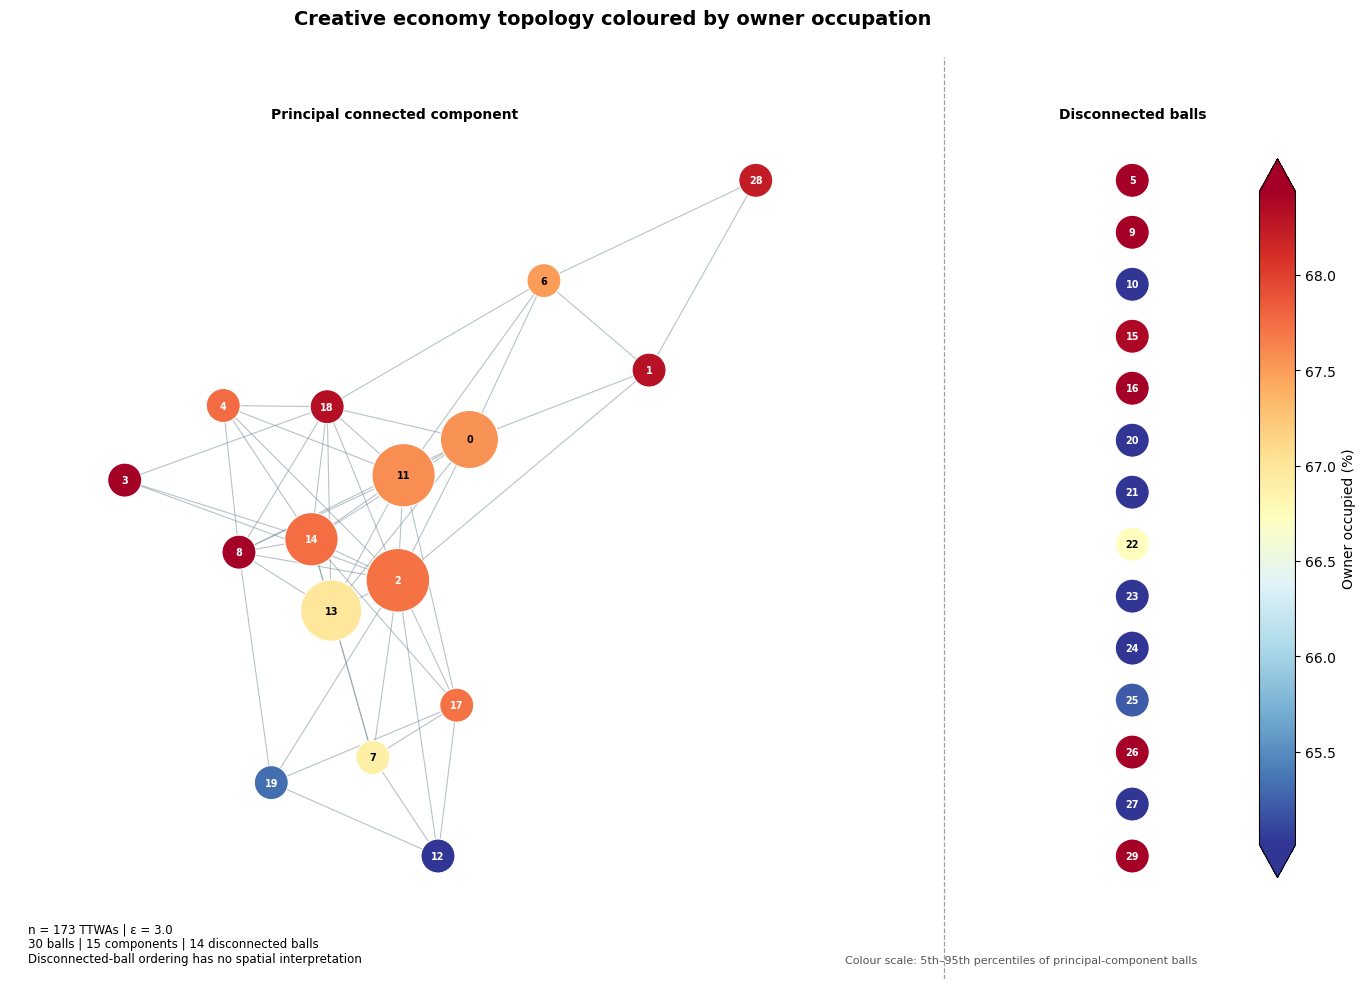

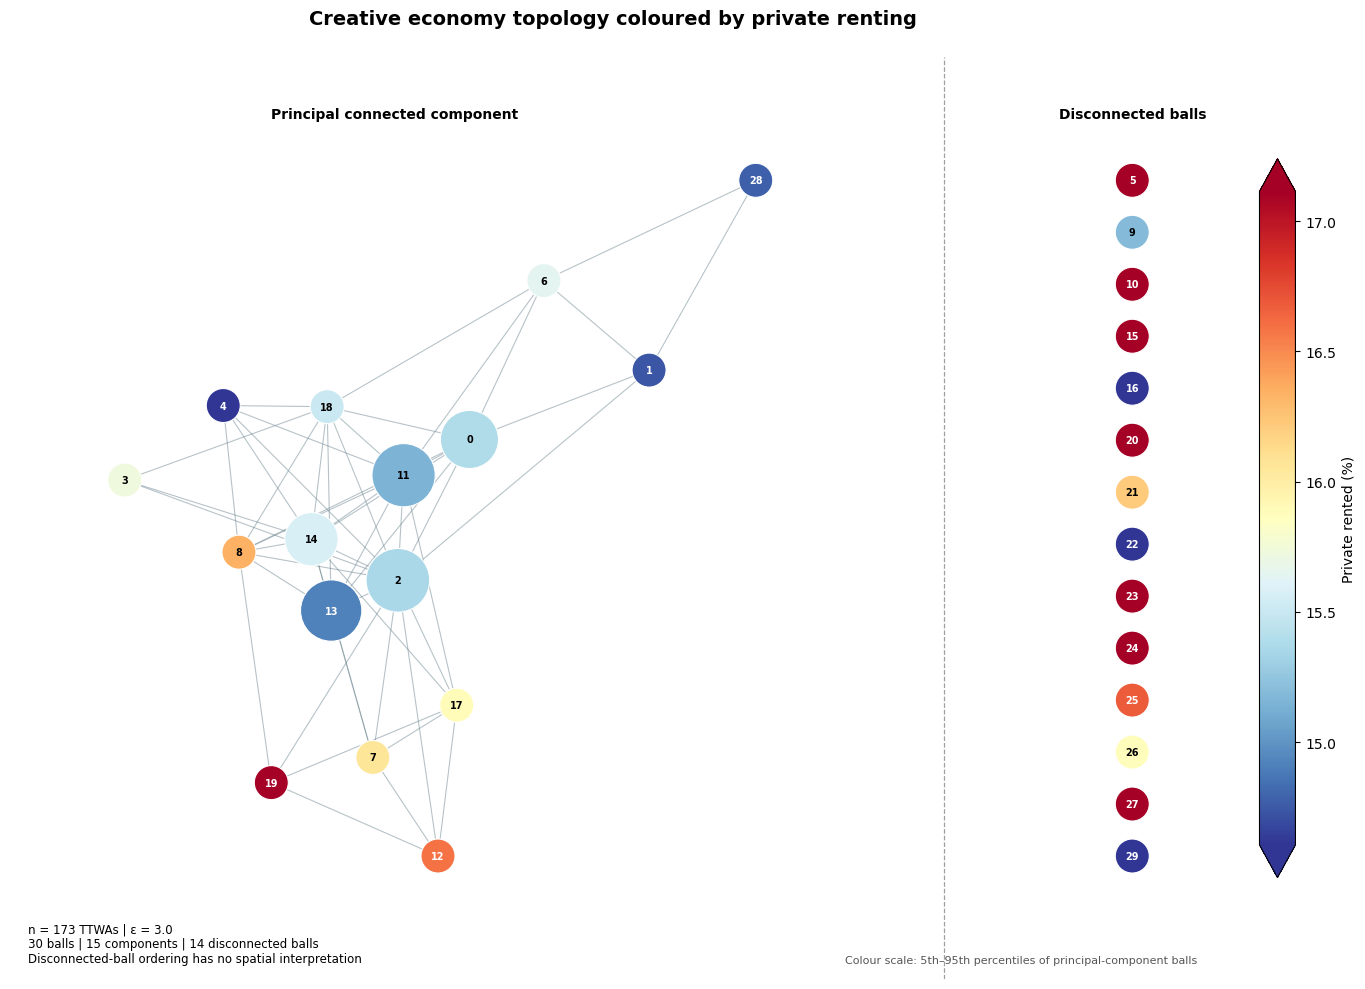

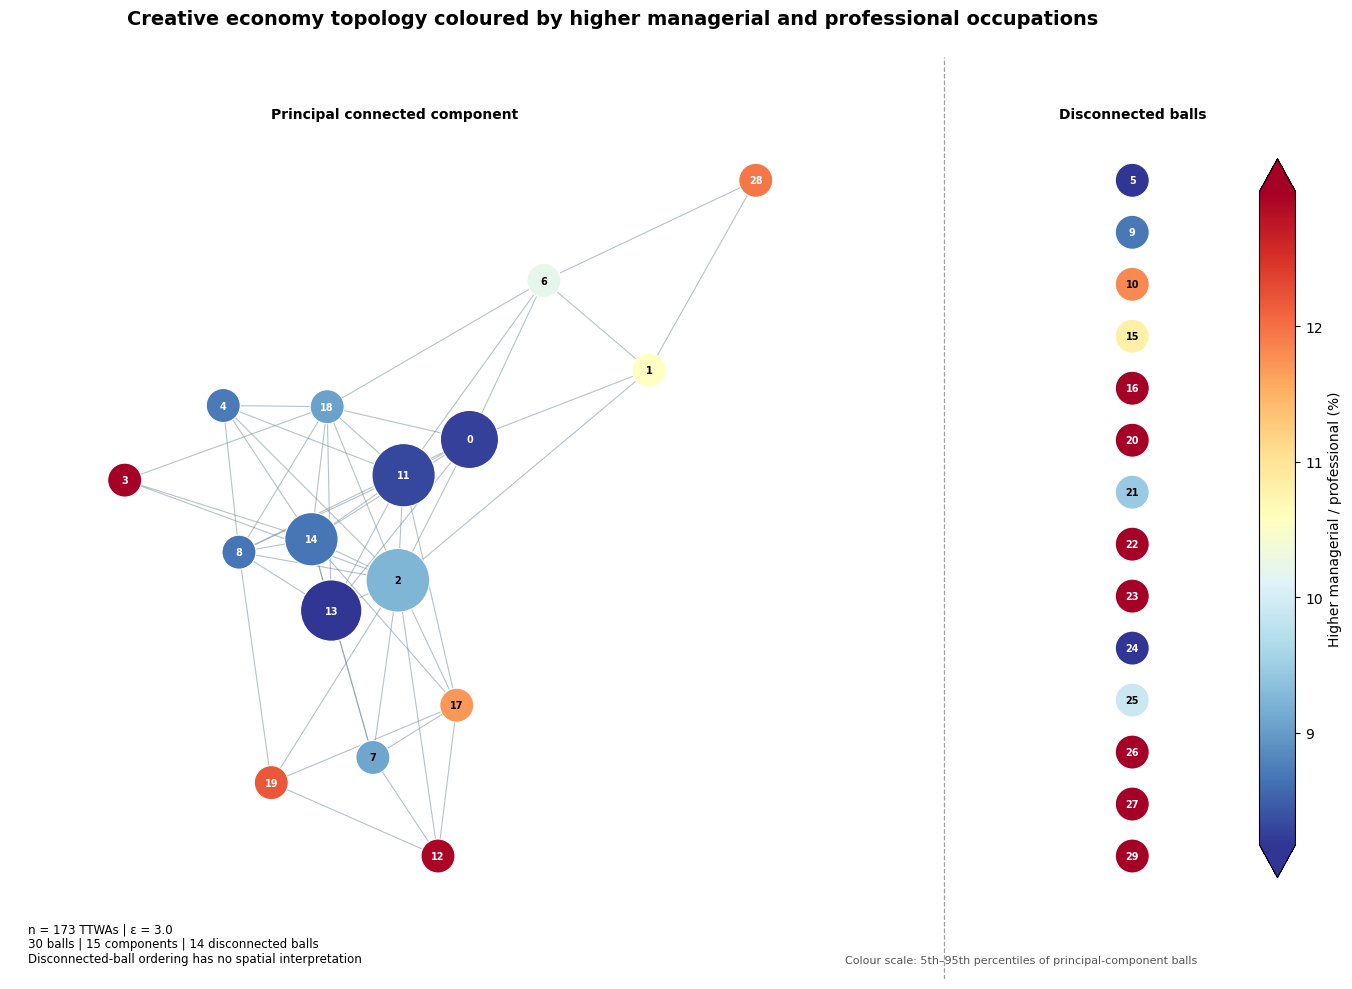

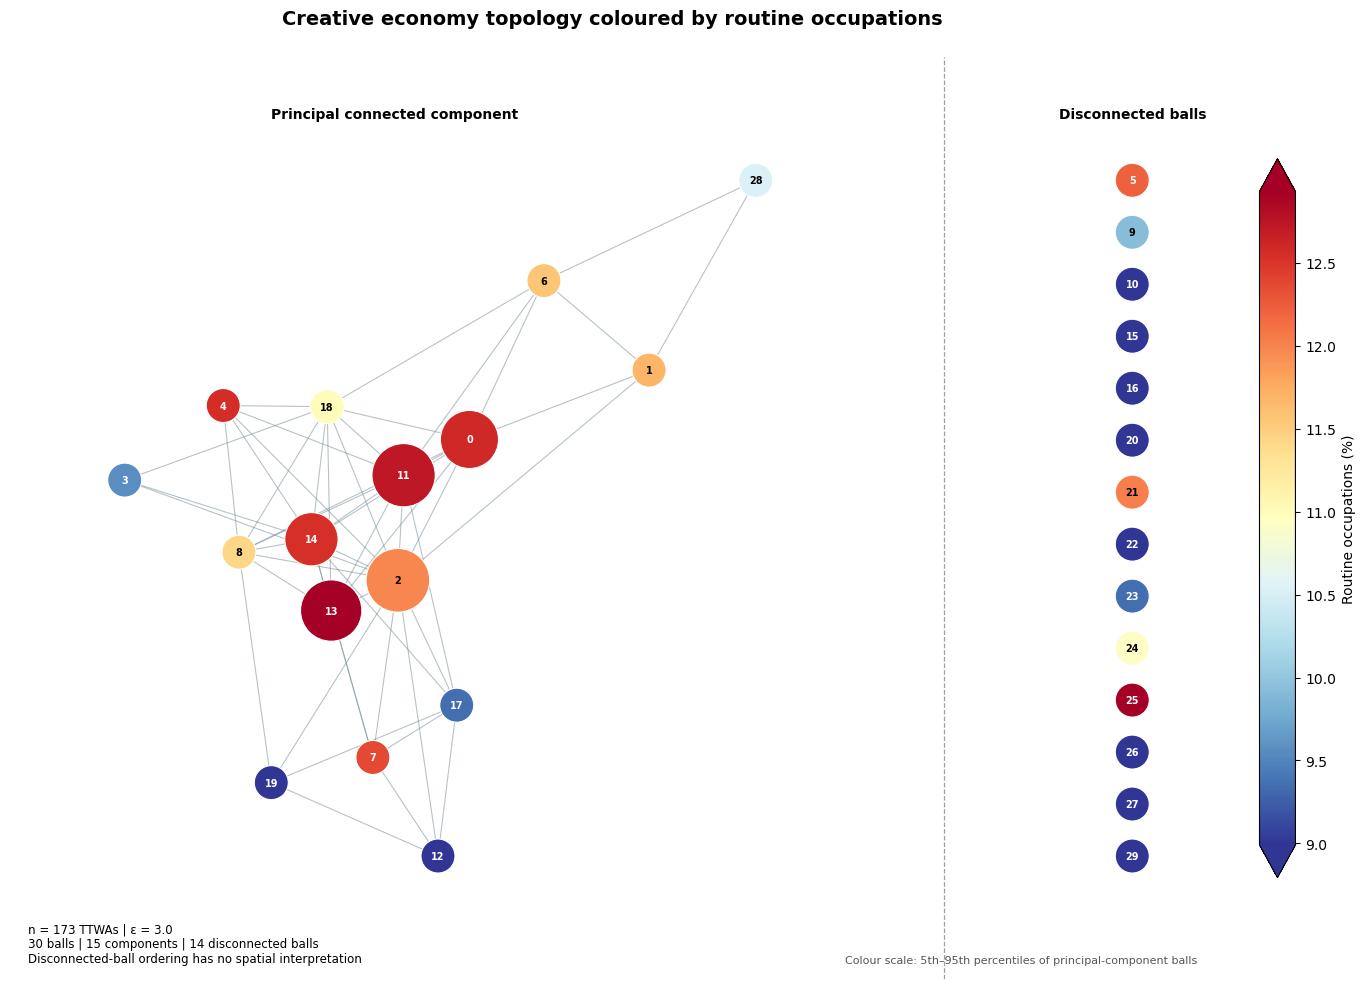

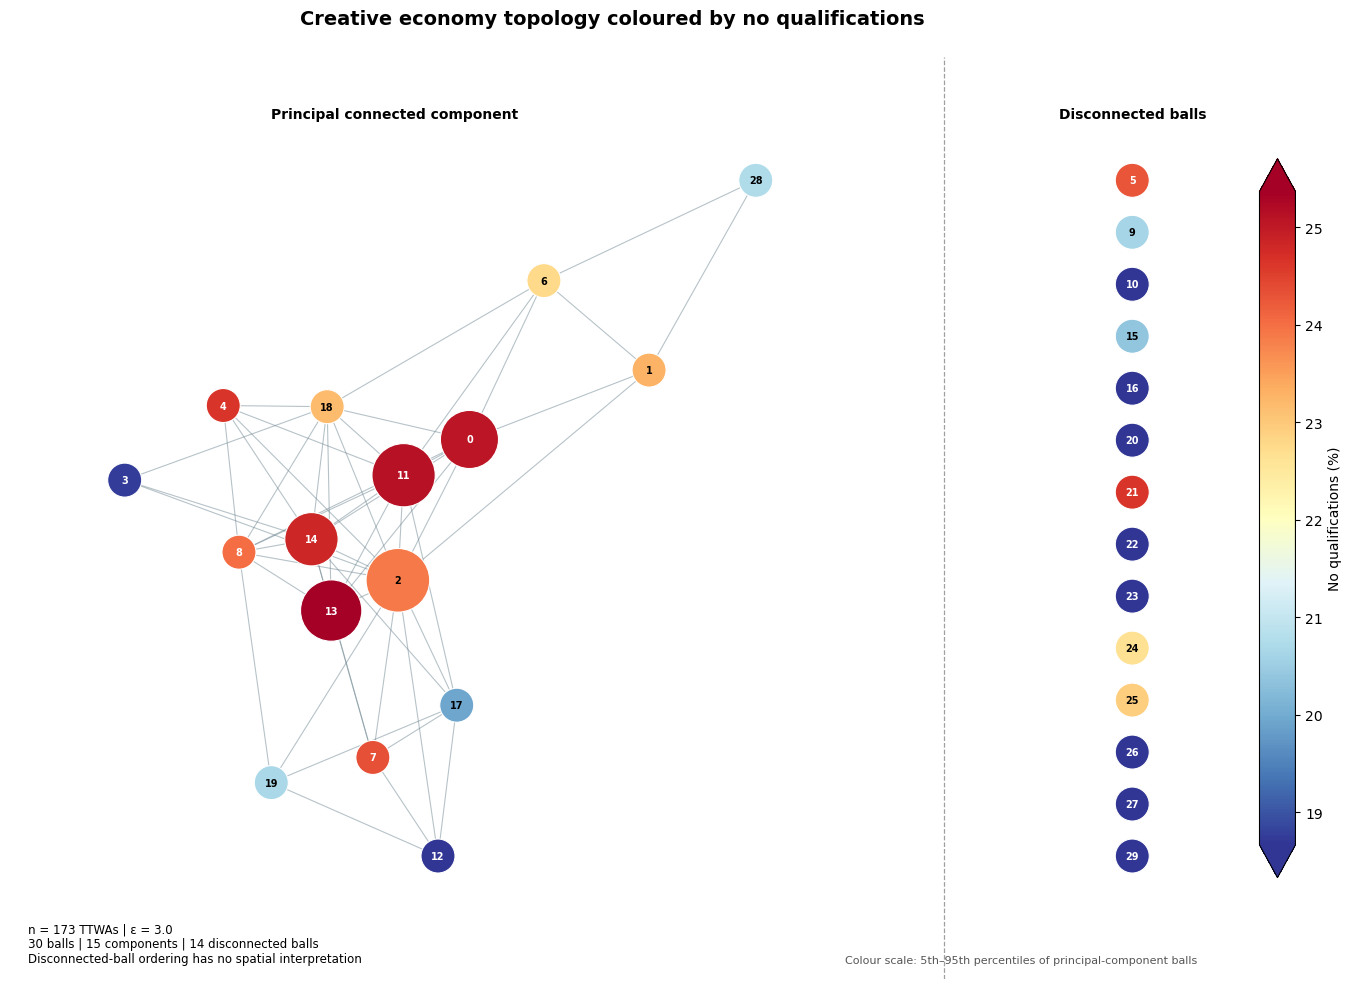

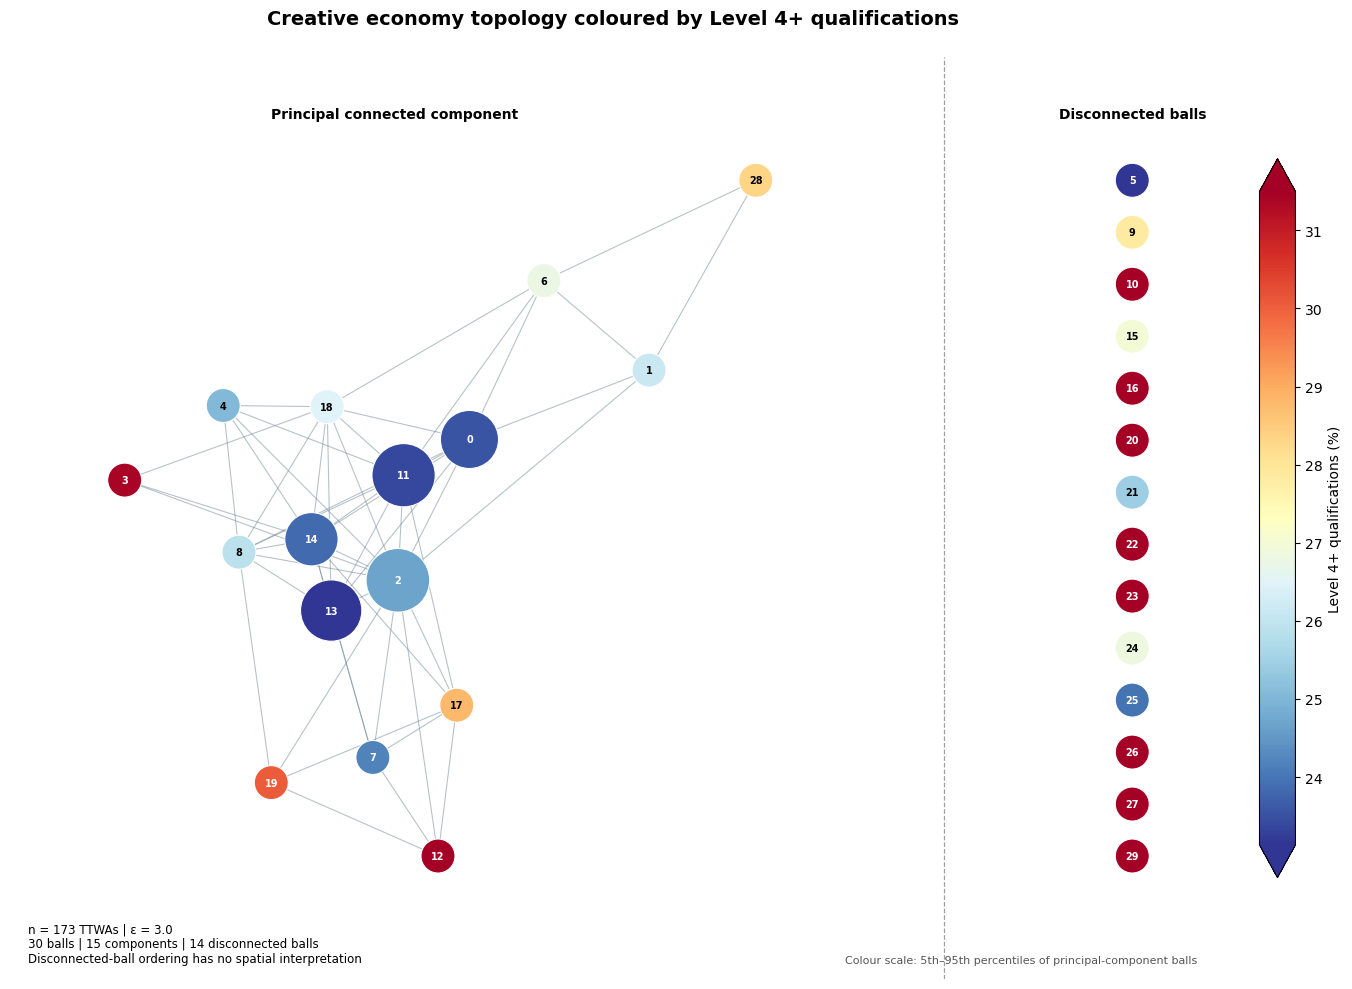

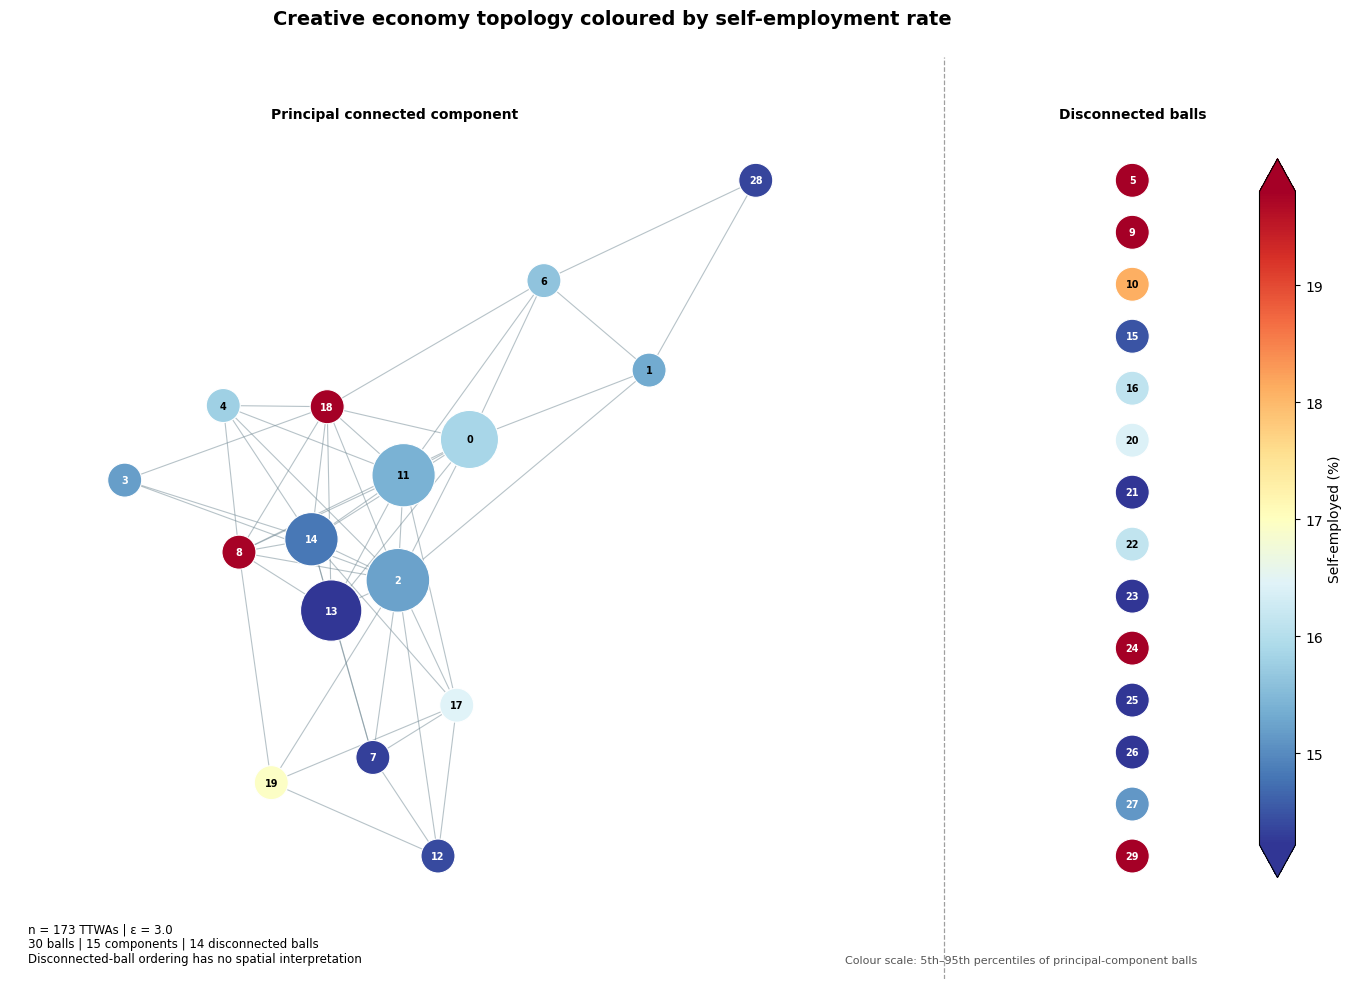

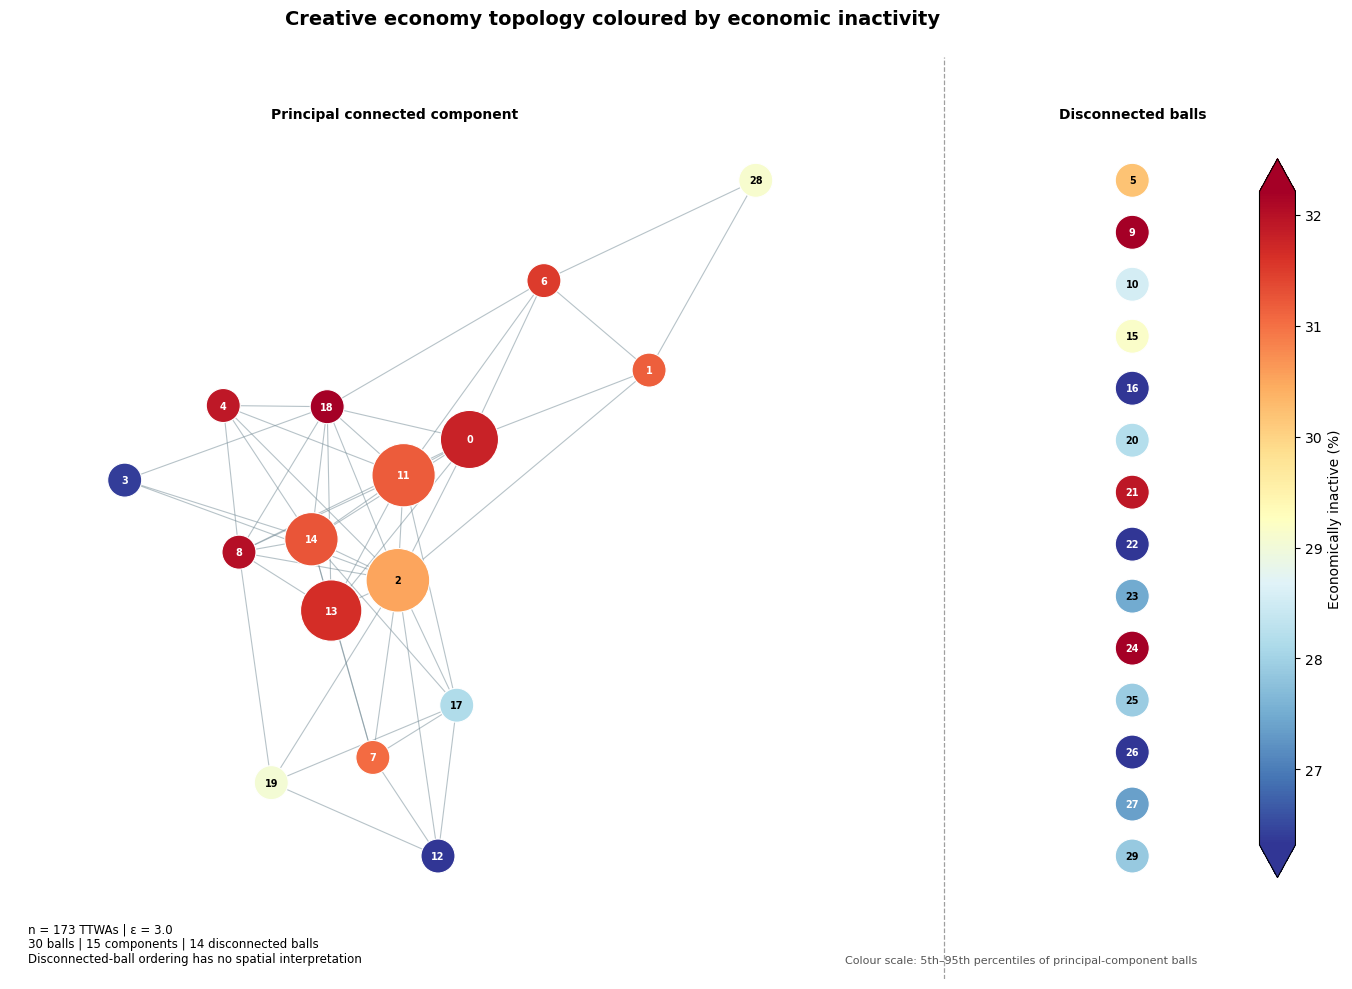

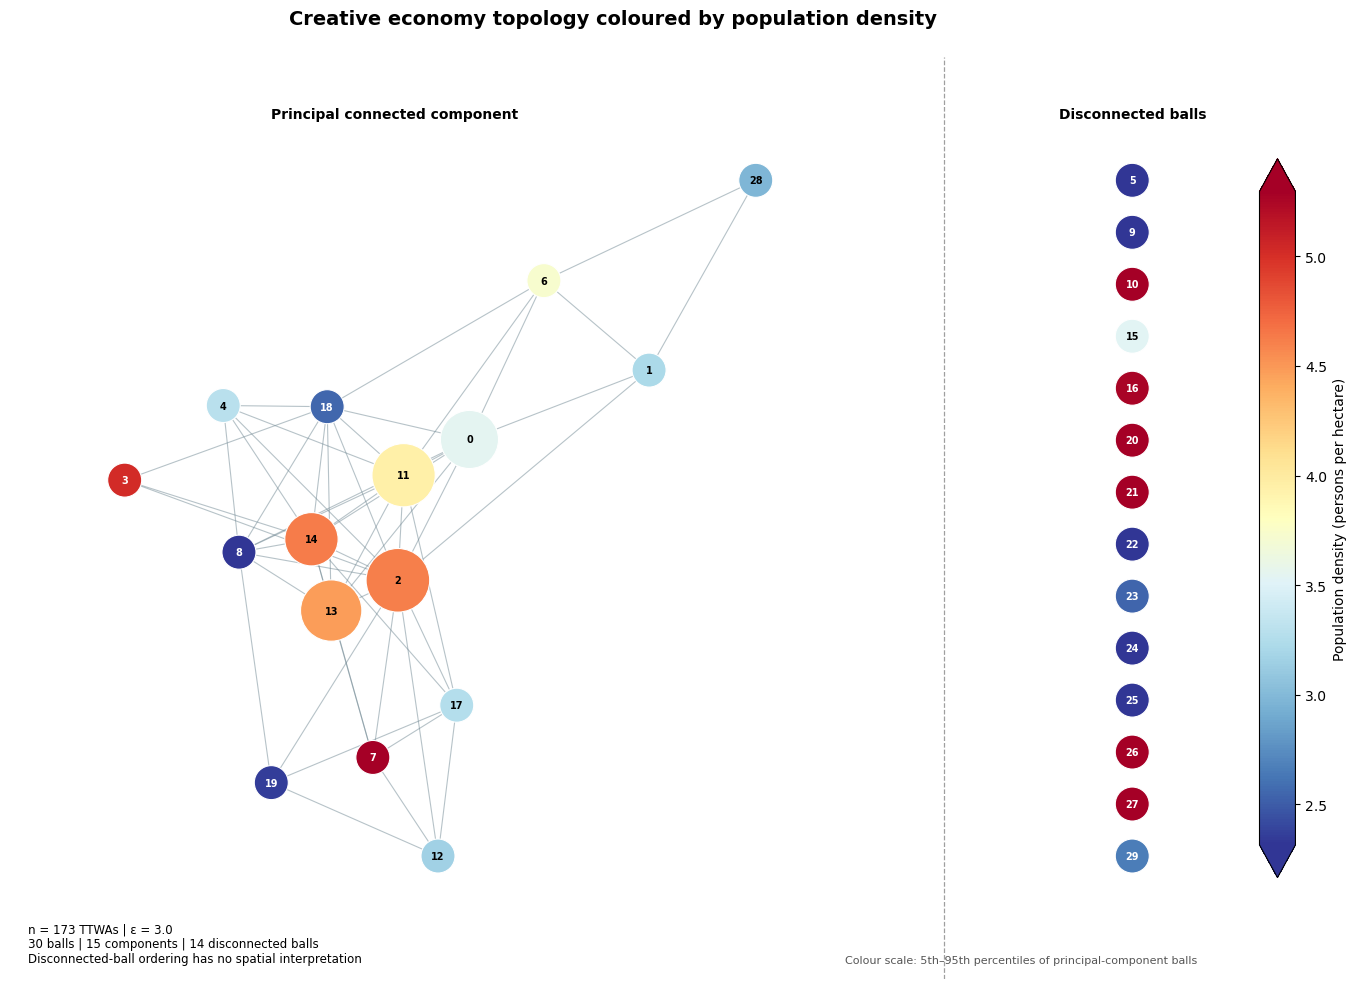

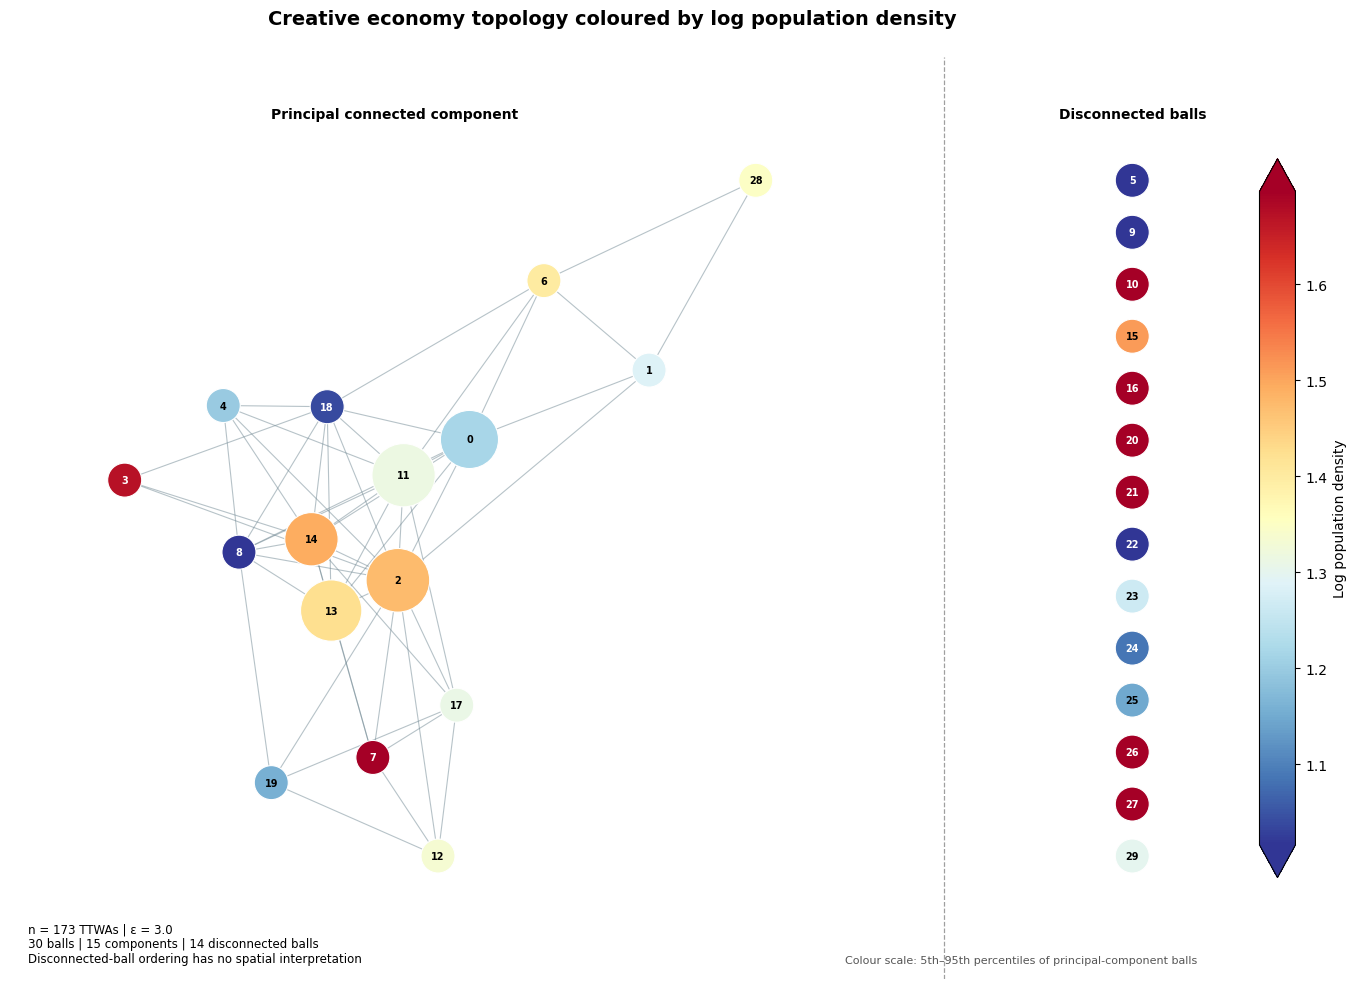

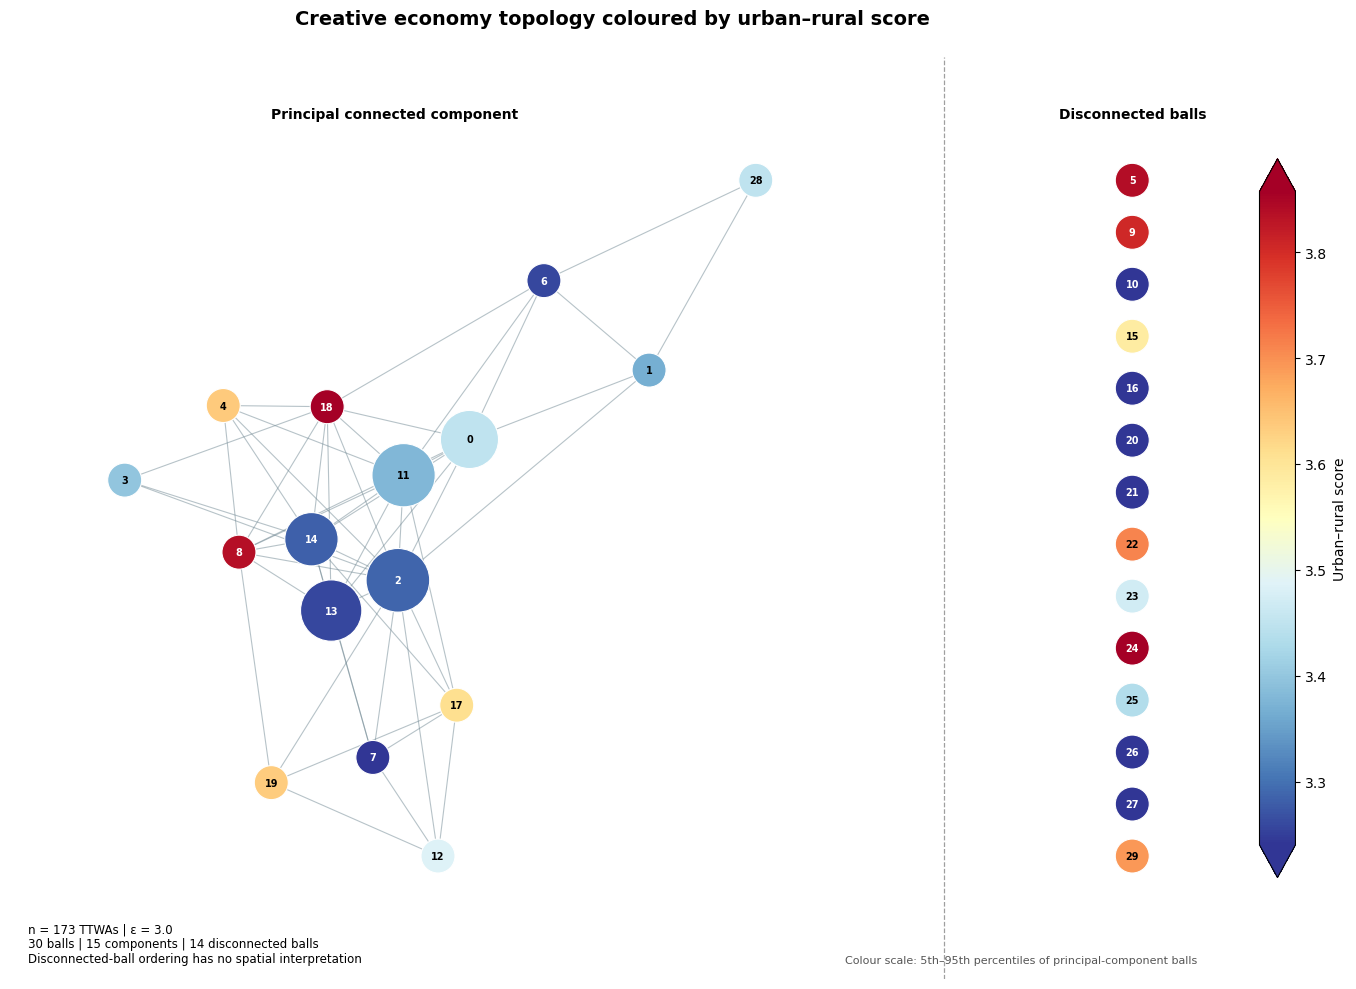

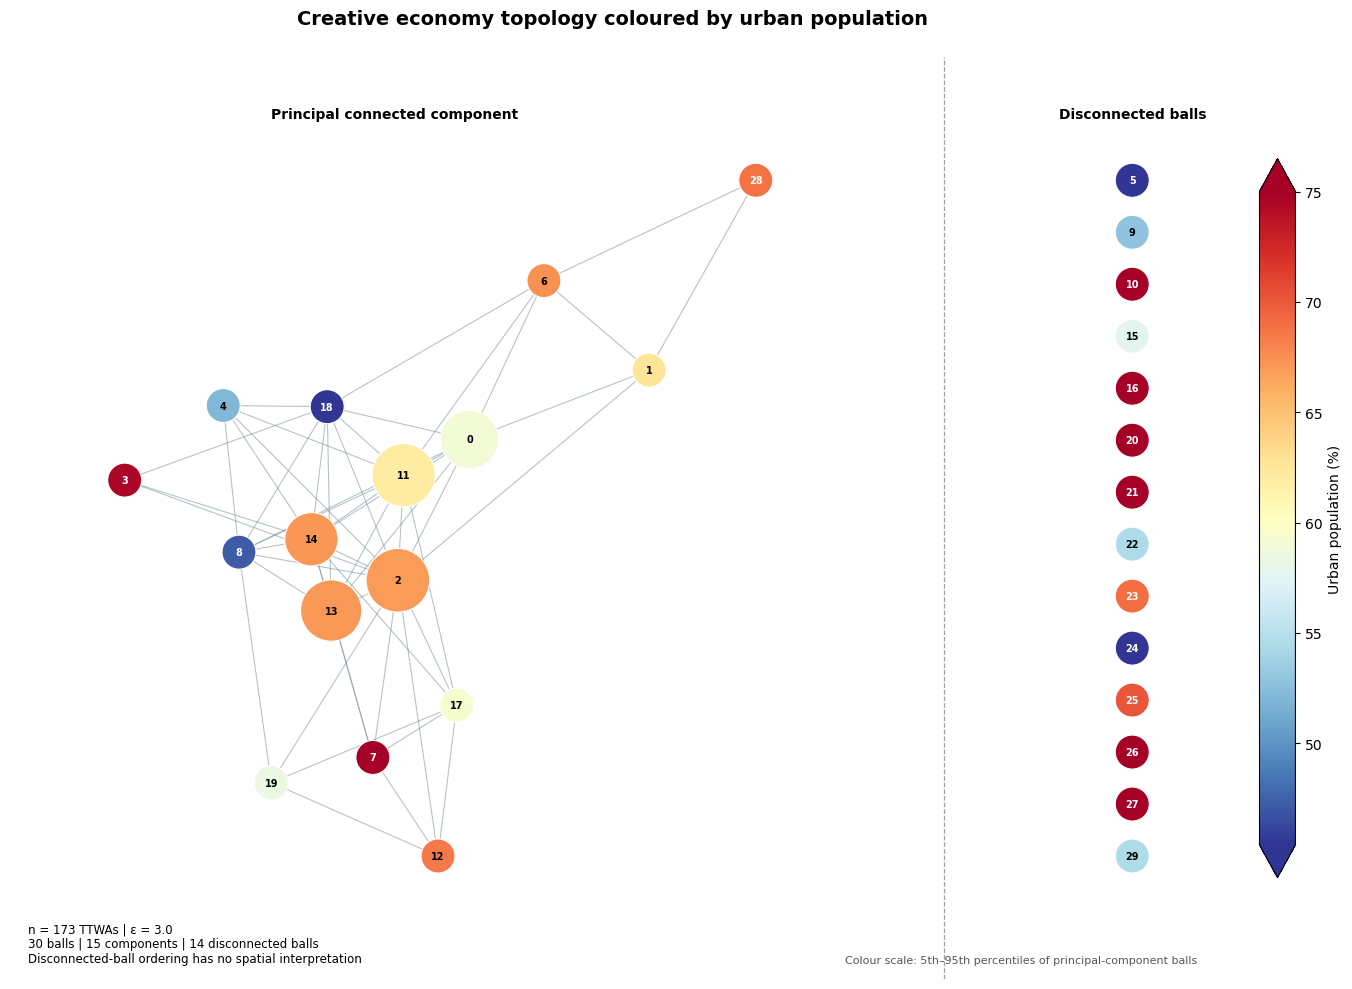

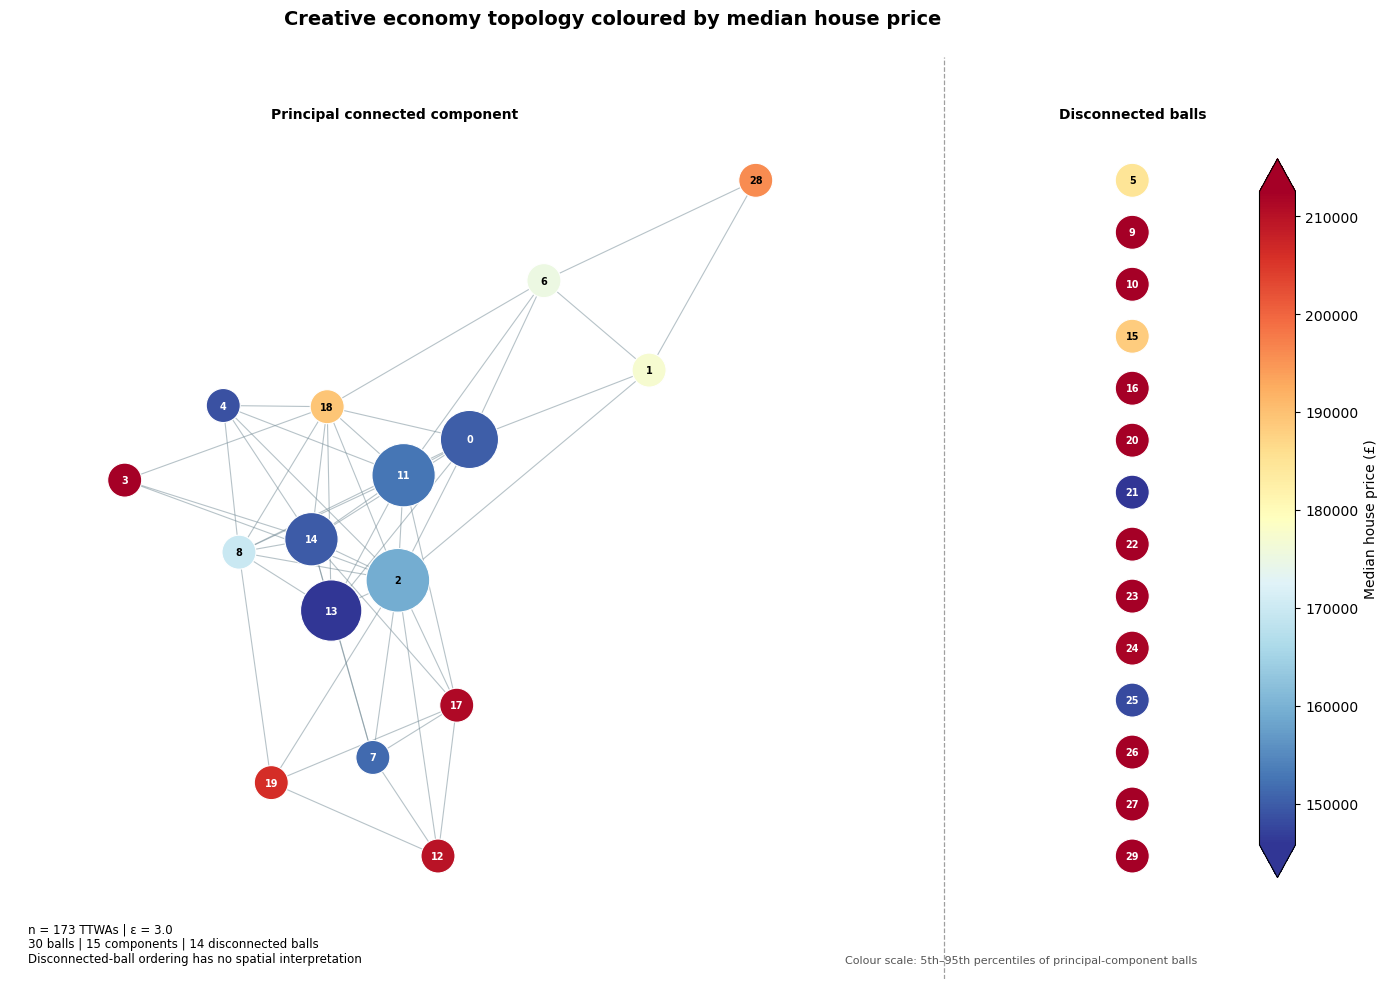

In [14]:
for census_col, information in census_plots.items():

    values_by_ball = {}

    for ball in G_full.nodes:

        ttwas_in_ball = nesta.iloc[
            ball_members[ball]
        ]["ttwa"]

        matched_values = census.loc[
            census["TTWA11NM"].isin(ttwas_in_ball),
            census_col
        ]

        values_by_ball[ball] = matched_values.mean()

    plot_full_ballmapper_values(
        values_by_ball=values_by_ball,
        title=information["title"],
        cbar_label=information["label"],
        G=G_full,
        pos=pos_full,
        size_dict=node_size_dict,
        disconnected_nodes=disconnected_nodes,
        layout_information=layout_information,
        centre=None,
        cmap_name="RdYlBu_r"
    )

Creating a data table for further analysis

In [15]:
import pandas as pd
import numpy as np
import networkx as nx

short_names = {
    "Advertising and marketing: Employment 2011-2014_LQ":
        "Advertising_LQ",

    "Architecture: Employment 2011-2014_LQ":
        "Architecture_LQ",

    "Design: product, graphic and fashion design: Employment 2011-2014_LQ":
        "Design_LQ",

    "Film, TV, video, radio and photography: Employment 2011-2014_LQ":
        "Film_TV_LQ",

    "IT, software and computer services: Employment 2011-2014_LQ":
        "IT_Software_LQ",

    "Music, performing and visual arts: Employment 2011-2014_LQ":
        "Music_Arts_LQ",

    "Publishing: Employment 2011-2014_LQ":
        "Publishing_LQ"
}

# Identify the principal connected component
main_component = set(
    max(nx.connected_components(G_full), key=len)
)

isolated_balls = set(nx.isolates(G_full))

ball_profile_rows = []

for ball in sorted(G_full.nodes):

    row_indices = ball_members[ball]

    ball_data = nesta.iloc[row_indices]

    row = {
        "ball": ball,
        "component_status": (
            "Principal component"
            if ball in main_component
            else "Disconnected"
        ),
        "is_isolate": ball in isolated_balls,
        "n_ttwas": len(row_indices),
        "ttwas": "; ".join(
            sorted(ball_data["ttwa"].tolist())
        )
    }

    for original_col, short_col in short_names.items():
        row[short_col] = ball_data[original_col].mean()

    ball_profile_rows.append(row)

ball_profiles_full = pd.DataFrame(ball_profile_rows)

In [16]:
lq_short_cols = list(short_names.values())

def identify_top_sectors(row):

    sector_values = row[lq_short_cols].sort_values(
        ascending=False
    )

    dominant_col = sector_values.index[0]
    second_col = sector_values.index[1]

    return pd.Series({
        "dominant_sector": dominant_col.replace("_LQ", ""),
        "dominant_LQ": sector_values.iloc[0],
        "second_sector": second_col.replace("_LQ", ""),
        "second_LQ": sector_values.iloc[1],
        "dominance_gap": (
            sector_values.iloc[0] -
            sector_values.iloc[1]
        )
    })


top_sector_information = ball_profiles_full.apply(
    identify_top_sectors,
    axis=1
)

ball_profiles_full = pd.concat(
    [
        ball_profiles_full,
        top_sector_information
    ],
    axis=1
)

In [17]:
column_order = [
    "ball",
    "component_status",
    "is_isolate",
    "n_ttwas",
    "dominant_sector",
    "dominant_LQ",
    "second_sector",
    "second_LQ",
    "dominance_gap",
    "Advertising_LQ",
    "Architecture_LQ",
    "Design_LQ",
    "Film_TV_LQ",
    "IT_Software_LQ",
    "Music_Arts_LQ",
    "Publishing_LQ",
    "ttwas"
]

ball_profiles_full = (
    ball_profiles_full[column_order]
    .sort_values("ball")
    .reset_index(drop=True)
)

numeric_columns = [
    "dominant_LQ",
    "second_LQ",
    "dominance_gap",
    *lq_short_cols
]

ball_profiles_full[numeric_columns] = (
    ball_profiles_full[numeric_columns]
    .round(2)
)

ball_profiles_full

,ball,component_status,is_isolate,n_ttwas,dominant_sector,dominant_LQ,second_sector,second_LQ,dominance_gap,Advertising_LQ,Architecture_LQ,Design_LQ,Film_TV_LQ,IT_Software_LQ,Music_Arts_LQ,Publishing_LQ,ttwas
0,0,Principal component,False,70,Architecture,0.75,Design,0.67,0.09,0.34,0.75,0.67,0.21,0.44,0.61,0.49,Aberystwyth; Barnsley; Berwick; Bideford; Birk...
1,1,Principal component,False,9,Publishing,2.01,Design,1.07,0.93,0.48,0.88,1.07,0.30,0.72,0.69,2.01,Andover; Barrow-in-Furness; Basingstoke; Cambr...
2,2,Principal component,False,84,Design,0.86,Architecture,0.80,0.06,0.45,0.80,0.86,0.30,0.66,0.70,0.36,Ashford; Barnsley; Bedford; Birkenhead; Birmin...
3,3,Principal component,False,3,IT_Software,1.53,Design,1.47,0.06,1.02,1.17,1.47,0.89,1.53,1.08,0.50,Banbury; Bristol; High Wycombe and Aylesbury
4,4,Principal component,False,9,Film_TV,0.94,Design,0.83,0.11,0.29,0.75,0.83,0.94,0.45,0.82,0.30,Bangor and Holyhead; Cardiff; Cinderford and R...
5,5,Disconnected,True,1,Advertising,3.08,Music_Arts,1.34,1.74,3.08,0.91,0.78,0.23,0.27,1.34,0.17,Barnstaple
6,6,Principal component,False,8,Publishing,2.09,Architecture,1.18,0.90,0.47,1.18,1.16,0.27,0.59,0.85,2.09,Barrow-in-Furness; Bath; Cambridge; Chichester...
7,7,Principal component,False,11,Advertising,1.03,Design,0.75,0.28,1.03,0.63,0.75,0.22,0.58,0.53,0.36,Blackburn; Blackpool; Bournemouth; Corby; Leed...
8,8,Principal component,False,23,Music_Arts,1.31,Design,1.14,0.18,0.36,0.96,1.14,0.44,0.43,1.31,0.32,Blandford Forum and Gillingham; Brecon; Bridli...
9,9,Disconnected,True,2,Design,2.67,Music_Arts,1.34,1.33,0.42,0.73,2.67,0.81,0.28,1.34,0.34,Bridport; Falmouth


In [18]:
assert len(ball_profiles_full) == G_full.number_of_nodes()
assert set(ball_profiles_full["ball"]) == set(G_full.nodes)

print("Balls in graph:", G_full.number_of_nodes())
print("Balls in table:", len(ball_profiles_full))
print(
    "Principal-component balls:",
    (ball_profiles_full["component_status"]
     == "Principal component").sum()
)
print(
    "Disconnected balls:",
    (ball_profiles_full["component_status"]
     == "Disconnected").sum()
)

Balls in graph: 30
Balls in table: 30
Principal-component balls: 16
Disconnected balls: 14


In [19]:
ball_profiles_full.to_csv(
    "/Users/scandimimi/Documents/Manchester/ERP/"
    "ball_profiles_full_epsilon_3.csv",
    index=False
)

Investigating the isolated balls:

In [20]:
isolated_balls = sorted(nx.isolates(G_full))

sector_names = {
    "Advertising and marketing: Employment 2011-2014_LQ":
        "Advertising and marketing",

    "Architecture: Employment 2011-2014_LQ":
        "Architecture",

    "Design: product, graphic and fashion design: Employment 2011-2014_LQ":
        "Design: product, graphic and fashion design",

    "Film, TV, video, radio and photography: Employment 2011-2014_LQ":
        "Film, TV, video, radio and photography",

    "IT, software and computer services: Employment 2011-2014_LQ":
        "IT, software and computer services",

    "Music, performing and visual arts: Employment 2011-2014_LQ":
        "Music, performing and visual arts",

    "Publishing: Employment 2011-2014_LQ":
        "Publishing"
}

isolated_ttwa_rows = []

for ball in isolated_balls:


    row_indices = ball_members[ball]

    for row_index in row_indices:

        ttwa_row = nesta.iloc[row_index]

        # LQ values for this individual TTWA
        lq_values = ttwa_row[lq_cols].astype(float)

        dominant_column = lq_values.idxmax()
        dominant_lq = lq_values.max()

        isolated_ttwa_rows.append({
            "ttwa": ttwa_row["ttwa"],
            "isolated_ball": ball,
            "dominant_sector": sector_names[dominant_column],
            "dominant_LQ": dominant_lq
        })

isolated_ttwa_table = pd.DataFrame(
    isolated_ttwa_rows
)

isolated_ttwa_table["dominant_LQ"] = (
    isolated_ttwa_table["dominant_LQ"]
    .round(2)
)

isolated_ttwa_table = (
    isolated_ttwa_table
    .sort_values(
        ["dominant_LQ", "isolated_ball"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

isolated_ttwa_table

,ttwa,isolated_ball,dominant_sector,dominant_LQ
0,Peterborough,25,Publishing,15.20
1,Penzance,24,"Film, TV, video, radio and photography",9.93
2,Colchester,15,Publishing,6.11
3,Reading,26,"IT, software and computer services",4.48
4,Guildford and Aldershot,16,"IT, software and computer services",3.97
5,Oxford,23,Publishing,3.63
6,Brighton,10,"Music, performing and visual arts",3.11
7,Barnstaple,5,Advertising and marketing,3.08
8,Newbury,22,"IT, software and computer services",3.03
9,Tunbridge Wells,29,Publishing,2.75


In [21]:
lq_cols = [
    "Advertising and marketing: Employment 2011-2014_LQ",
    "Architecture: Employment 2011-2014_LQ",
    "Design: product, graphic and fashion design: Employment 2011-2014_LQ",
    "Film, TV, video, radio and photography: Employment 2011-2014_LQ",
    "IT, software and computer services: Employment 2011-2014_LQ",
    "Music, performing and visual arts: Employment 2011-2014_LQ",
    "Publishing: Employment 2011-2014_LQ"
]

nesta["max_sector_LQ"] = nesta[lq_cols].max(axis=1)

no_specialisation = nesta[nesta["max_sector_LQ"] <= 1]

n_no_specialisation = len(no_specialisation)
n_total = len(nesta)

print(
    f"{n_no_specialisation} of {n_total} TTWAs "
    f"({n_no_specialisation / n_total * 100:.1f}%) "
    "have no creative sub-sector with LQ > 1."
)

65 of 173 TTWAs (37.6%) have no creative sub-sector with LQ > 1.


Ball breakdowns by Census data: 

In [22]:
census_cols = [
    "pct_owned",
    "pct_private_rented",
    "pct_higher_managerial",
    "pct_routine",
    "pct_no_quals",
    "pct_level4_plus",
    "pct_self_employed",
    "pct_econ_inactive",
    "pop_density",
    "log_pop_density",
    "urban_rural_score",
    "pct_urban",
    "median_house_price",
]

stat_rows = []

for ball in sorted(G_full.nodes):

    ttwas_in_ball = nesta.iloc[ball_members[ball]]["ttwa"]

    matched = census.loc[
        census["TTWA11NM"].isin(ttwas_in_ball),
        census_cols
    ]

    summary = matched.agg(
        ["mean", "std", "min", "median", "max"]
    ).T

    summary["ball"] = ball
    summary["variable"] = summary.index
    summary["n_ttwas"] = len(matched)

    stat_rows.append(summary.reset_index(drop=True))

ball_census_stats = pd.concat(stat_rows, ignore_index=True)

ball_census_stats = ball_census_stats[
    ["ball", "variable", "n_ttwas", "mean", "std", "min", "median", "max"]
]

ball_census_stats[["mean", "std", "min", "median", "max"]] = (
    ball_census_stats[["mean", "std", "min", "median", "max"]]
    .astype(float)
    .round(2)
)

ball_census_stats

,ball,variable,n_ttwas,mean,std,min,median,max
0,0,pct_owned,70,67.54,3.38,57.91,68.18,76.46
1,0,pct_private_rented,70,15.38,2.48,10.88,15.07,22.08
2,0,pct_higher_managerial,70,8.25,1.64,5.02,8.02,12.57
3,0,pct_routine,70,12.59,2.13,8.31,11.94,17.98
4,0,pct_no_quals,70,25.07,3.53,19.31,24.68,35.24
...,...,...,...,...,...,...,...,...
385,29,pop_density,1,2.66,NaN,2.66,2.66,2.66
386,29,log_pop_density,1,1.30,NaN,1.30,1.30,1.30
387,29,urban_rural_score,1,3.69,NaN,3.69,3.69,3.69
388,29,pct_urban,1,54.50,NaN,54.50,54.50,54.50


Putting the above table into Wide-form 

In [23]:
assert set(ball_census_stats["ball"]) == set(G_full.nodes)
assert (
    ball_census_stats.groupby("ball")["variable"].count() == len(census_cols)
).all()


ball_census_means = (
    ball_census_stats
    .pivot(index="ball", columns="variable", values="mean")
    [census_cols]
    .add_suffix("_mean")
    .reset_index()
)

ball_profiles_full = ball_profiles_full.merge(
    ball_census_means,
    on="ball",
    how="left"
)

assert len(ball_profiles_full) == G_full.number_of_nodes()

ball_profiles_full

,ball,component_status,is_isolate,n_ttwas,dominant_sector,dominant_LQ,second_sector,second_LQ,dominance_gap,Advertising_LQ,...,pct_routine_mean,pct_no_quals_mean,pct_level4_plus_mean,pct_self_employed_mean,pct_econ_inactive_mean,pop_density_mean,log_pop_density_mean,urban_rural_score_mean,pct_urban_mean,median_house_price_mean
0,0,Principal component,False,70,Architecture,0.75,Design,0.67,0.09,0.34,...,12.59,25.07,23.55,15.87,31.80,3.54,1.22,3.45,58.98,150090.14
1,1,Principal component,False,9,Publishing,2.01,Design,1.07,0.93,0.48,...,11.69,23.29,26.13,15.31,31.17,3.22,1.29,3.37,62.55,177105.61
2,2,Principal component,False,84,Design,0.86,Architecture,0.80,0.06,0.45,...,11.98,23.90,24.70,15.23,30.52,4.61,1.47,3.29,67.00,159256.86
3,3,Principal component,False,3,IT_Software,1.53,Design,1.47,0.06,1.02,...,9.57,18.77,31.42,15.20,26.41,5.02,1.67,3.40,74.57,216500.00
4,4,Principal component,False,9,Film_TV,0.94,Design,0.83,0.11,0.29,...,12.56,24.65,25.04,15.77,31.91,3.29,1.20,3.64,52.07,148779.06
5,5,Disconnected,True,1,Advertising,3.08,Music_Arts,1.34,1.74,3.08,...,12.21,24.29,22.70,20.87,30.20,0.86,0.62,3.84,45.39,184750.00
6,6,Principal component,False,8,Publishing,2.09,Architecture,1.18,0.90,0.47,...,11.57,22.76,26.77,15.63,31.51,3.73,1.40,3.26,67.46,175181.31
7,7,Principal component,False,11,Advertising,1.03,Design,0.75,0.28,1.03,...,12.37,24.33,24.18,14.32,31.04,6.13,1.77,3.19,76.31,151326.05
8,8,Principal component,False,23,Music_Arts,1.31,Design,1.14,0.18,0.36,...,11.43,24.03,25.89,19.76,32.01,2.18,0.94,3.84,47.17,169763.54
9,9,Disconnected,True,2,Design,2.67,Music_Arts,1.34,1.33,0.42,...,9.92,20.62,27.86,23.30,34.70,1.48,0.89,3.81,52.87,220000.00
